# Emergency Department Triage Acuity: EDA, Preprocessing, and Modeling

This notebook analyzes emergency department triage data and builds a supervised model to predict `triage_acuity` from information available at triage time.

The workflow is organized into four parts:

| Part | Sections | Purpose |
|---|---|---|
| Data understanding | Setup, loading, integrity checks, EDA | Understand target distribution, clinical signals, missingness, leakage risk, and text-template risk |
| Preprocessing | Feature engineering, validation, drift checks, processed outputs | Create aligned train/test feature tables without post-triage leakage |
| Modeling preparation | Feature groups, ablation design, validation strategy | Convert EDA findings into controlled model experiments |
| Modeling experiments | Logistic Regression, LightGBM, XGBoost, CatBoost, final submission | Compare models, select a safety-prioritized final model, and generate `submission.csv` |

Clinical priority: lower `triage_acuity` values indicate higher urgency. The most important modeling goal is to identify high-acuity patients (`triage_acuity` 1/2) while minimizing severe undertriage.


## 0. Project Setup And Modeling Constraints

This section defines paths, constants, feature groups used during EDA, and the core modeling constraints.

Key constraints:

- `triage_acuity` is the target label and must not be used as a feature.
- `disposition` and `ed_los_hours` are post-triage outcomes. They are leakage because they are only known after triage decisions are made.
- `patient_id` is only for merging related files and preserving row alignment for downstream outputs. It must not be used as a model feature.
- `chief_complaint_raw` contains repeated templates and can create shortcut learning. Text models must be checked with grouped validation by `chief_complaint_raw_clean`.


In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:  # Fallback for running as a plain Python script.
    display = print

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, f1_score, mean_absolute_error
from sklearn.model_selection import ParameterGrid, ParameterSampler, StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


## 0.1 Global Configuration

This cell defines display options, file paths, target/ID columns, leakage columns, and feature lists reused by EDA, preprocessing, and modeling.


In [3]:
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:.3f}".format)

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
COMPLAINTS_PATH = DATA_DIR / "chief_complaints.csv"
HISTORY_PATH = DATA_DIR / "patient_history.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

TARGET_COL = "triage_acuity"
ID_COL = "patient_id"
LEAKAGE_COLS = ["disposition", "ed_los_hours"]

KEY_CLINICAL_COLS = [
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score",
    "news2_score",
]

CORE_VITAL_COLS = [
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
]

CATEGORICAL_DRIFT_COLS = [
    "site_id",
    "triage_nurse_id",
    "arrival_mode",
    "language",
    "insurance_type",
    "transport_origin",
    "pain_location",
    "mental_status_triage",
    "chief_complaint_system",
]

NUMERIC_DRIFT_COLS = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score_clean",
    "news2_score",
]


## 1. Load Raw Data

Load the raw train/test tables, chief complaint text table, patient history table, and sample submission template. The raw data is kept unchanged; all modeling-ready transformations are created later in processed copies.


In [4]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
chief_complaints = pd.read_csv(COMPLAINTS_PATH)
patient_history = pd.read_csv(HISTORY_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

raw_shapes = pd.DataFrame(
    {
        "dataset": ["train", "test", "chief_complaints", "patient_history", "sample_submission"],
        "rows": [len(train), len(test), len(chief_complaints), len(patient_history), len(sample_submission)],
        "columns": [train.shape[1], test.shape[1], chief_complaints.shape[1], patient_history.shape[1], sample_submission.shape[1]],
    }
)
display(raw_shapes)

,dataset,rows,columns
0,train,80000,40
1,test,20000,37
2,chief_complaints,100000,3
3,patient_history,100000,26
4,sample_submission,20000,2


## 1.1 Dataset Citation And Terms Compliance

Competition requirement: all datasets used must be cited and described in the notebook, and use must comply with each dataset's access terms.

Current notebook data:

- This notebook uses the Triagegeist CSV dataset supplied with this project workspace: `train.csv`, `test.csv`, `chief_complaints.csv`, `patient_history.csv`, and `sample_submission.csv`.
- The data is used for an emergency triage acuity prediction system. Rows are linked by `patient_id`; `triage_acuity` is the training label; `disposition` and `ed_los_hours` are post-triage outcomes and are excluded from model training.
- If this notebook is published on Kaggle, the attached Kaggle Dataset/source page for these CSV files should be cited in the notebook metadata or writeup.

Relevant public datasets for extension or external validation:

| Dataset | Source | Access / Terms Note | Use In This Project |
|---|---|---|---|
| MIMIC-IV-ED | PhysioNet | Credentialed access; users must complete credentialing and sign the dataset Data Use Agreement | Not included here; optional future external validation source only |
| NHAMCS ED public-use files | CDC/NCHS | Public-use files; cite the exact year and documentation used | Optional future public validation source |

Citation notes:

- Current Triagegeist CSV dataset: cite the Kaggle competition or attached dataset page used for these files.
- MIMIC-IV-ED, if used later: Johnson et al., `MIMIC-IV-ED`, PhysioNet, Version 2.2, 2023, DOI `10.13026/5ntk-km72`.
- NHAMCS, if used later: cite CDC/NCHS NHAMCS Emergency Department public-use data documentation for the specific year(s) used.

Compliance statement:

- The current notebook uses the provided Triagegeist project CSV files.
- No restricted MIMIC-IV-ED data is included in this repository.
- Any future MIMIC-IV-ED use must follow PhysioNet credentialing and DUA requirements.
- Any future NHAMCS use should document the exact public-use file and year.


## 2. Data Integrity And Leakage Checks

Before EDA or preprocessing, verify row counts, uniqueness of `patient_id`, train/test column alignment, and availability of leakage-sensitive fields. This establishes which columns are safe for modeling and which are only useful for retrospective review.


In [5]:
def summarize_id_integrity(datasets, id_col=ID_COL):
    rows = []
    for name, df in datasets.items():
        rows.append(
            {
                "dataset": name,
                "rows": len(df),
                "unique_patient_id": df[id_col].nunique() if id_col in df.columns else np.nan,
                "duplicate_patient_id": int(df[id_col].duplicated().sum()) if id_col in df.columns else np.nan,
                "missing_patient_id": int(df[id_col].isna().sum()) if id_col in df.columns else np.nan,
            }
        )
    return pd.DataFrame(rows)

id_integrity = summarize_id_integrity(
    {
        "train": train,
        "test": test,
        "chief_complaints": chief_complaints,
        "patient_history": patient_history,
        "sample_submission": sample_submission,
    }
)
display(id_integrity)

train_ids = set(train[ID_COL])
test_ids = set(test[ID_COL])
complaint_ids = set(chief_complaints[ID_COL])
history_ids = set(patient_history[ID_COL])

merge_coverage = pd.DataFrame(
    [
        {"dataset": "train", "missing_complaint_rows": len(train_ids - complaint_ids), "missing_history_rows": len(train_ids - history_ids)},
        {"dataset": "test", "missing_complaint_rows": len(test_ids - complaint_ids), "missing_history_rows": len(test_ids - history_ids)},
    ]
)
display(merge_coverage)

column_comparison = pd.DataFrame(
    {
        "train_only_columns": pd.Series(sorted(set(train.columns) - set(test.columns))),
        "test_only_columns": pd.Series(sorted(set(test.columns) - set(train.columns))),
    }
)
display(column_comparison)

,dataset,rows,unique_patient_id,duplicate_patient_id,missing_patient_id
0,train,80000,80000,0,0
1,test,20000,20000,0,0
2,chief_complaints,100000,100000,0,0
3,patient_history,100000,100000,0,0
4,sample_submission,20000,20000,0,0


,dataset,missing_complaint_rows,missing_history_rows
0,train,0,0
1,test,0,0


,train_only_columns,test_only_columns
0,disposition,NaN
1,ed_los_hours,NaN
2,triage_acuity,NaN


In [6]:
availability_table = pd.DataFrame(
    [
        {"column": ID_COL, "role": "merge/alignment only", "in_train": ID_COL in train.columns, "in_test": ID_COL in test.columns},
        {"column": TARGET_COL, "role": "target", "in_train": TARGET_COL in train.columns, "in_test": TARGET_COL in test.columns},
        *[
            {"column": col, "role": "post-triage leakage", "in_train": col in train.columns, "in_test": col in test.columns}
            for col in LEAKAGE_COLS
        ],
    ]
)
display(availability_table)

,column,role,in_train,in_test
0,patient_id,merge/alignment only,True,True
1,triage_acuity,target,True,False
2,disposition,post-triage leakage,True,False
3,ed_los_hours,post-triage leakage,True,False


In [7]:
# EDA-only merged training view. Preprocessing functions below perform the official transformations.
train_eda = train.merge(chief_complaints, on=ID_COL, how="left", suffixes=("", "_complaints"))
if "chief_complaint_system_complaints" in train_eda.columns:
    train_eda["chief_complaint_system"] = train_eda["chief_complaint_system"].combine_first(
        train_eda["chief_complaint_system_complaints"]
    )
    train_eda = train_eda.drop(columns=["chief_complaint_system_complaints"])
train_eda = train_eda.merge(patient_history, on=ID_COL, how="left")

print(f"EDA merged train shape: {train_eda.shape}")

EDA merged train shape: (80000, 66)


## 3.1 EDA: Target Distribution

Analyze the distribution of `triage_acuity`. Because the target is ordered and clinically asymmetric, later evaluation should not rely on accuracy alone. High-acuity patients are defined as acuity 1/2.


,triage_acuity,count,percent
0,1,3222,4.027
1,2,13439,16.799
2,3,28921,36.151
3,4,23020,28.775
4,5,11398,14.247


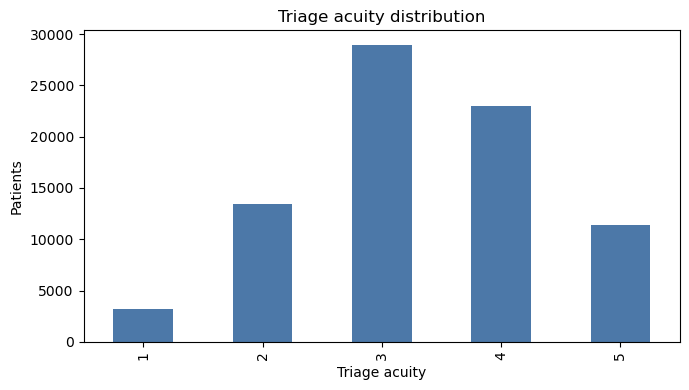

In [8]:
target_distribution = (
    train[TARGET_COL]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(TARGET_COL)
    .reset_index(name="count")
)
target_distribution["percent"] = target_distribution["count"] / len(train) * 100
display(target_distribution)

ax = target_distribution.plot.bar(x=TARGET_COL, y="count", legend=False, figsize=(7, 4), color="#4C78A8")
ax.set_title("Triage acuity distribution")
ax.set_xlabel("Triage acuity")
ax.set_ylabel("Patients")
plt.tight_layout()
plt.show()

In [9]:
high_acuity_summary = pd.DataFrame(
    {
        "group": ["ESI 1-2", "ESI 3", "ESI 4-5"],
        "count": [
            int(train[TARGET_COL].isin([1, 2]).sum()),
            int((train[TARGET_COL] == 3).sum()),
            int(train[TARGET_COL].isin([4, 5]).sum()),
        ],
    }
)
high_acuity_summary["percent"] = high_acuity_summary["count"] / len(train) * 100
display(high_acuity_summary)

,group,count,percent
0,ESI 1-2,16661,20.826
1,ESI 3,28921,36.151
2,ESI 4-5,34418,43.023


## 3.2 EDA: Missingness And Invalid Clinical Values

Check missing values and clinically impossible values in vital signs and scoring fields. Invalid values are not dropped; later preprocessing converts them to missing and keeps indicator features so the model can learn whether measurement quality itself carries signal.


In [10]:
missing_summary = (
    train_eda.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_rate"})
)
missing_summary["missing_count"] = train_eda[missing_summary["column"]].isna().sum().to_numpy()
display(missing_summary.query("missing_count > 0").head(30))

clinical_missing_by_acuity = (
    train_eda.groupby(TARGET_COL)[[col for col in KEY_CLINICAL_COLS if col in train_eda.columns]]
    .apply(lambda x: x.isna().mean())
    .reset_index()
)
display(clinical_missing_by_acuity)

,column,missing_rate,missing_count
0,shock_index,0.052,4146
1,pulse_pressure,0.052,4146
2,systolic_bp,0.052,4146
3,diastolic_bp,0.052,4146
4,mean_arterial_pressure,0.052,4146
5,respiratory_rate,0.038,3067
6,temperature_c,0.007,574


,triage_acuity,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,news2_score
0,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,4,0.121,0.121,0.000,0.089,0.000,0.000,0.000,0.000,0.000
4,5,0.118,0.118,0.000,0.089,0.050,0.000,0.000,0.000,0.000


In [11]:
invalid_rules = {
    "pain_score": lambda s: (s < 0) | (s > 10),
    "gcs_total": lambda s: (s < 3) | (s > 15),
    "spo2": lambda s: (s < 0) | (s > 100),
    "temperature_c": lambda s: (s < 30) | (s > 45),
    "heart_rate": lambda s: (s < 20) | (s > 250),
    "respiratory_rate": lambda s: (s < 3) | (s > 80),
    "systolic_bp": lambda s: (s < 40) | (s > 300),
    "diastolic_bp": lambda s: (s < 20) | (s > 200),
}

invalid_summary = []
for col, rule in invalid_rules.items():
    if col in train_eda.columns:
        invalid_summary.append({"column": col, "invalid_count": int(rule(train_eda[col]).sum())})

if {"systolic_bp", "diastolic_bp"}.issubset(train_eda.columns):
    invalid_summary.append(
        {
            "column": "systolic_bp_lt_diastolic_bp",
            "invalid_count": int((train_eda["systolic_bp"] < train_eda["diastolic_bp"]).sum()),
        }
    )

display(pd.DataFrame(invalid_summary))

pain_score_clean_eda = train_eda["pain_score"].where(train_eda["pain_score"].between(0, 10))
missing_vital_count_eda = train_eda[[col for col in CORE_VITAL_COLS if col in train_eda.columns]].isna().sum(axis=1)

display(
    pd.DataFrame(
        {
            "pain_score_clean_missing_rate": [pain_score_clean_eda.isna().mean()],
            "mean_missing_vital_count": [missing_vital_count_eda.mean()],
            "max_missing_vital_count": [missing_vital_count_eda.max()],
        }
    )
)

,column,invalid_count
0,pain_score,11156
1,gcs_total,0
2,spo2,0
3,temperature_c,0
4,heart_rate,0
5,respiratory_rate,0
6,systolic_bp,0
7,diastolic_bp,0
8,systolic_bp_lt_diastolic_bp,2087


,pain_score_clean_missing_rate,mean_missing_vital_count,max_missing_vital_count
0,0.139,0.149,4


## 3.3 EDA: Clinical Numerical Variables

Inspect vital signs, severity scores, and derived clinical indicators by acuity. This section identifies strong clinical-rule signals such as NEWS2, GCS, oxygen saturation, respiratory rate, fever, hypotension, and pain.


In [12]:
clinical_numeric_cols = [
    col
    for col in [
        "age",
        "systolic_bp",
        "diastolic_bp",
        "mean_arterial_pressure",
        "pulse_pressure",
        "heart_rate",
        "respiratory_rate",
        "temperature_c",
        "spo2",
        "gcs_total",
        "pain_score",
        "news2_score",
        "shock_index",
    ]
    if col in train_eda.columns
]

clinical_summary_by_acuity = train_eda.groupby(TARGET_COL)[clinical_numeric_cols].median().T
display(clinical_summary_by_acuity)

triage_acuity,1,2,3,4,5
age,49.000,48.000,48.000,48.000,48.000
systolic_bp,82.600,100.400,126.000,132.000,128.100
diastolic_bp,52.150,63.300,76.900,80.000,78.800
mean_arterial_pressure,62.100,75.500,93.300,97.300,95.300
pulse_pressure,30.300,37.300,49.300,52.100,49.000
heart_rate,119.200,108.700,93.000,84.100,76.800
respiratory_rate,28.000,23.000,18.000,16.000,15.000
temperature_c,38.900,38.500,37.700,37.200,36.900
spo2,85.900,92.000,96.000,98.000,99.000
gcs_total,6.500,12.000,15.000,15.000,15.000


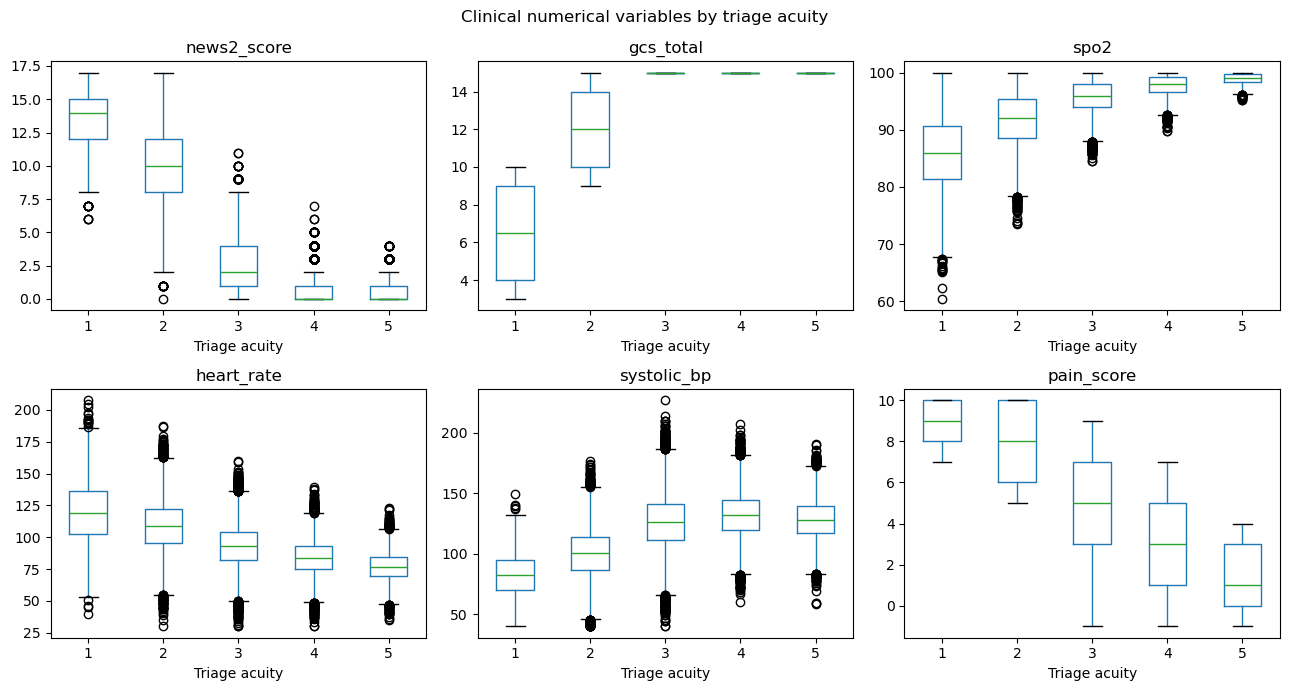

In [13]:
plot_cols = [col for col in ["news2_score", "gcs_total", "spo2", "heart_rate", "systolic_bp", "pain_score"] if col in train_eda.columns]
if plot_cols:
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(13, 7))
    axes = axes.ravel()
    for ax, col in zip(axes, plot_cols):
        train_eda.boxplot(column=col, by=TARGET_COL, ax=ax, grid=False)
        ax.set_title(col)
        ax.set_xlabel("Triage acuity")
    for ax in axes[len(plot_cols):]:
        ax.axis("off")
    fig.suptitle("Clinical numerical variables by triage acuity")
    plt.tight_layout()
    plt.show()

In [14]:
clinical_flag_rules = {
    "high_news2": ("news2_score", lambda s: s >= 5),
    "low_gcs": ("gcs_total", lambda s: s < 15),
    "very_low_gcs": ("gcs_total", lambda s: s <= 8),
    "low_spo2": ("spo2", lambda s: s < 94),
    "very_low_spo2": ("spo2", lambda s: s < 90),
    "tachypnea": ("respiratory_rate", lambda s: s >= 22),
    "fever": ("temperature_c", lambda s: s >= 38),
    "severe_pain": ("pain_score", lambda s: pain_score_clean_eda >= 8),
    "hypotension": ("systolic_bp", lambda s: s < 90),
}

clinical_flags_eda = pd.DataFrame(index=train_eda.index)
for flag, (source_col, rule) in clinical_flag_rules.items():
    if source_col in train_eda.columns:
        clinical_flags_eda[flag] = rule(train_eda[source_col]).fillna(False).astype(int)

if not clinical_flags_eda.empty:
    flag_rates_by_acuity = clinical_flags_eda.join(train_eda[TARGET_COL]).groupby(TARGET_COL).mean().T
    display(flag_rates_by_acuity)

triage_acuity,1,2,3,4,5
high_news2,1.000,0.978,0.143,0.001,0.000
low_gcs,1.000,0.856,0.000,0.000,0.000
very_low_gcs,0.745,0.000,0.000,0.000,0.000
low_spo2,0.873,0.651,0.246,0.020,0.000
very_low_spo2,0.716,0.342,0.022,0.000,0.000
tachypnea,0.840,0.580,0.094,0.001,0.000
fever,0.863,0.758,0.359,0.065,0.004
severe_pain,0.806,0.571,0.233,0.000,0.000
hypotension,0.654,0.305,0.048,0.009,0.008


## 3.4 EDA: Categorical Variables

Review categorical features available at triage, including arrival context, demographic categories, transport origin, mental status, pain location, site, and nurse identifiers. Operational identifiers are inspected but later tested with sensitivity analysis.


In [15]:
def normalized_crosstab_by_target(df, column, target=TARGET_COL, max_levels=12):
    if column not in df.columns or target not in df.columns:
        return pd.DataFrame()
    top_levels = df[column].fillna("__MISSING__").value_counts().head(max_levels).index
    subset = df[df[column].fillna("__MISSING__").isin(top_levels)].copy()
    subset[column] = subset[column].fillna("__MISSING__")
    return pd.crosstab(subset[column], subset[target], normalize="index")

categorical_cols = [
    col
    for col in [
        "site_id",
        "arrival_mode",
        "shift",
        "age_group",
        "sex",
        "language",
        "insurance_type",
        "transport_origin",
        "pain_location",
        "mental_status_triage",
        "chief_complaint_system",
    ]
    if col in train_eda.columns
]

categorical_cardinality = pd.DataFrame(
    {
        "column": categorical_cols,
        "unique_levels": [train_eda[col].nunique(dropna=False) for col in categorical_cols],
        "missing_rate": [train_eda[col].isna().mean() for col in categorical_cols],
    }
)
display(categorical_cardinality)

for col in ["mental_status_triage", "arrival_mode", "chief_complaint_system"]:
    table = normalized_crosstab_by_target(train_eda, col)
    if not table.empty:
        print(f"\n{col}: target distribution within top levels")
        display(table)

,column,unique_levels,missing_rate
0,site_id,5,0.000
1,arrival_mode,6,0.000
2,shift,4,0.000
3,age_group,4,0.000
4,sex,3,0.000
5,language,8,0.000
6,insurance_type,5,0.000
7,transport_origin,7,0.000
8,pain_location,9,0.000
9,mental_status_triage,5,0.000



mental_status_triage: target distribution within top levels


triage_acuity,1,2,3,4,5
mental_status_triage,,,,,
agitated,0.055,0.345,0.392,0.189,0.019
alert,0.001,0.030,0.342,0.399,0.229
confused,0.011,0.279,0.516,0.162,0.033
drowsy,0.087,0.445,0.313,0.129,0.026
unresponsive,0.426,0.446,0.128,0.000,0.000



arrival_mode: target distribution within top levels


triage_acuity,1,2,3,4,5
arrival_mode,,,,,
ambulance,0.041,0.167,0.360,0.289,0.143
brought_by_family,0.043,0.169,0.359,0.283,0.146
helicopter,0.047,0.153,0.375,0.283,0.141
police,0.039,0.171,0.359,0.282,0.149
transfer,0.039,0.162,0.364,0.291,0.144
walk-in,0.040,0.170,0.362,0.288,0.141



chief_complaint_system: target distribution within top levels


triage_acuity,1,2,3,4,5
chief_complaint_system,,,,,
ENT,0.041,0.176,0.356,0.287,0.140
cardiovascular,0.038,0.166,0.362,0.295,0.139
endocrine,0.046,0.172,0.368,0.280,0.134
gastrointestinal,0.040,0.176,0.371,0.272,0.141
genitourinary,0.037,0.165,0.352,0.297,0.148
infectious,0.040,0.170,0.354,0.288,0.147
musculoskeletal,0.037,0.164,0.363,0.295,0.141
neurological,0.036,0.164,0.358,0.293,0.149
ophthalmic,0.041,0.161,0.366,0.285,0.148


In [16]:
if "chief_complaint_system" in train_eda.columns:
    top_complaint_systems = (
        train_eda["chief_complaint_system"]
        .fillna("__MISSING__")
        .value_counts()
        .head(15)
        .rename_axis("chief_complaint_system")
        .reset_index(name="count")
    )
    top_complaint_systems["percent"] = top_complaint_systems["count"] / len(train_eda) * 100
    display(top_complaint_systems)

,chief_complaint_system,count,percent
0,gastrointestinal,5812,7.265
1,respiratory,5804,7.255
2,infectious,5764,7.205
3,endocrine,5749,7.186
4,musculoskeletal,5733,7.166
5,trauma,5726,7.157
6,genitourinary,5724,7.155
7,cardiovascular,5718,7.147
8,neurological,5691,7.114
9,psychiatric,5688,7.110


## 3.5 EDA: Chief Complaint Text

`chief_complaint_raw` is clinically important because it describes why the patient came to the emergency department. It is also high risk for shortcut learning because many complaints are templated. Later text models must compare random validation against grouped validation by cleaned complaint text.


In [17]:
if "chief_complaint_raw" in train_eda.columns:
    complaint_text = train_eda["chief_complaint_raw"].fillna("unknown").astype(str).str.strip().str.lower()
    complaint_text_summary = pd.DataFrame(
        {
            "missing_rate": [train_eda["chief_complaint_raw"].isna().mean()],
            "unique_raw_complaints": [complaint_text.nunique()],
            "duplicate_text_row_rate": [complaint_text.duplicated(keep=False).mean()],
            "median_char_len": [complaint_text.str.len().median()],
            "median_word_count": [complaint_text.str.split().str.len().median()],
        }
    )
    display(complaint_text_summary)

    top_raw_complaints = complaint_text.value_counts().head(20).rename_axis("chief_complaint_raw_clean").reset_index(name="count")
    display(top_raw_complaints)

,missing_rate,unique_raw_complaints,duplicate_text_row_rate,median_char_len,median_word_count
0,0.000,4949,0.998,39.000,5.000


,chief_complaint_raw_clean,count
0,sti with systemic features in known patient,44
1,new-onset jaundice with vomiting,43
2,"chest tightness with dyspnoea, onset today",41
3,"electrolyte imbalance symptomatic, worsening w...",41
4,"sudden visual blurring, for 2 days",41
5,electrolyte imbalance symptomatic，worsening ov...,41
6,exertional chest pain with associated nausea,41
7,"acute stress reaction, worsening with movement",41
8,"moderate low back pain, for 2 days",40
9,"dyspnoea on exertion, for 2 days",40


In [18]:
if "chief_complaint_raw" in train_eda.columns:
    complaint_target = pd.DataFrame({"complaint": complaint_text, TARGET_COL: train_eda[TARGET_COL]})
    repeated_complaints = complaint_target.groupby("complaint").filter(lambda x: len(x) >= 20)
    complaint_shortcut_summary = (
        repeated_complaints.groupby("complaint")[TARGET_COL]
        .agg(total="size", dominant_acuity=lambda s: s.value_counts().idxmax(), dominant_share=lambda s: s.value_counts(normalize=True).max())
        .sort_values(["dominant_share", "total"], ascending=False)
        .head(20)
        .reset_index()
    )
    display(complaint_shortcut_summary)

    keyword_patterns = {
        "chest_pain": "chest",
        "shortness_of_breath": "shortness|sob|breath",
        "abdominal_pain": "abdominal|abdomen",
        "fever": "fever",
        "trauma": "fall|injury|trauma|mvc",
        "neuro": "stroke|weakness|seizure|confusion",
    }
    keyword_rates = []
    for label, pattern in keyword_patterns.items():
        mask = complaint_text.str.contains(pattern, regex=True, na=False)
        keyword_rates.append(
            {
                "keyword_group": label,
                "row_count": int(mask.sum()),
                "high_acuity_rate_esi_1_2": train_eda.loc[mask, TARGET_COL].isin([1, 2]).mean() if mask.any() else np.nan,
            }
        )
    display(pd.DataFrame(keyword_rates))

,complaint,total,dominant_acuity,dominant_share
0,sti with systemic features in known patient,44,3,1.000
1,new-onset jaundice with vomiting,43,3,1.000
2,"acute stress reaction, worsening with movement",41,3,1.000
3,"chest tightness with dyspnoea, onset today",41,3,1.000
4,"electrolyte imbalance symptomatic, worsening w...",41,3,1.000
5,electrolyte imbalance symptomatic，worsening ov...,41,3,1.000
6,exertional chest pain with associated nausea,41,3,1.000
7,"sudden visual blurring, for 2 days",41,3,1.000
8,"cellulitis localised, worsening with movement",40,3,1.000
9,"dyspnoea on exertion, for 2 days",40,3,1.000


,keyword_group,row_count,high_acuity_rate_esi_1_2
0,chest_pain,2060,0.089
1,shortness_of_breath,0,NaN
2,abdominal_pain,1629,0.276
3,fever,7712,0.174
4,trauma,3648,0.372
5,neuro,1456,0.259


## 3.6 EDA: Patient History

Inspect patient comorbidity flags and prior utilization features. These variables represent baseline risk and should be compared separately from acute vital-sign features during modeling.


In [19]:
hx_cols = sorted([col for col in train_eda.columns if col.startswith("hx_")])
print(f"History columns found: {len(hx_cols)}")

if hx_cols:
    hx_summary = pd.DataFrame(
        {
            "column": hx_cols,
            "prevalence": [train_eda[col].fillna(0).mean() for col in hx_cols],
            "missing_rate": [train_eda[col].isna().mean() for col in hx_cols],
        }
    ).sort_values("prevalence", ascending=False)
    display(hx_summary.head(25))

    comorbidity_count_eda = train_eda[hx_cols].fillna(0).sum(axis=1)
    comorbidity_by_acuity = (
        pd.DataFrame({TARGET_COL: train_eda[TARGET_COL], "comorbidity_count": comorbidity_count_eda})
        .groupby(TARGET_COL)["comorbidity_count"]
        .agg(["mean", "median", "max"])
        .reset_index()
    )
    display(comorbidity_by_acuity)

History columns found: 25


,column,prevalence,missing_rate
6,hx_coronary_artery_disease,0.283,0.000
2,hx_atrial_fibrillation,0.282,0.000
3,hx_ckd,0.282,0.000
14,hx_hypertension,0.282,0.000
12,hx_heart_failure,0.281,0.000
10,hx_diabetes_type2,0.279,0.000
23,hx_stroke_prior,0.278,0.000
17,hx_immunosuppressed,0.201,0.000
15,hx_hyperthyroidism,0.199,0.000
18,hx_liver_disease,0.199,0.000


,triage_acuity,mean,median,max
0,1,6.617,6.000,19
1,2,6.476,6.000,20
2,3,5.052,5.000,17
3,4,5.047,5.000,17
4,5,5.023,5.000,17


## 4. Retrospective Outcome Consistency Check

This section uses `disposition` and `ed_los_hours` only for post-hoc consistency checks inside the training data. These variables are observed after triage, so they must never be used as model features. The goal is to identify patterns worth clinical review, not to label true undertriage.


Triage acuity vs disposition counts


disposition,admitted,deceased,discharged,lama,lwbs,observation,transferred,All
triage_acuity,,,,,,,,
1,2312,267,67,0,0,98,478,3222
2,8754,144,1641,125,128,1070,1577,13439
3,11049,0,10868,1116,1179,2358,2351,28921
4,2267,0,16609,1202,1566,693,683,23020
5,219,0,9843,321,783,118,114,11398
All,24601,411,39028,2764,3656,4337,5203,80000


Triage acuity vs disposition row percentages


disposition,admitted,deceased,discharged,lama,lwbs,observation,transferred
triage_acuity,,,,,,,
1,0.718,0.083,0.021,0.000,0.000,0.030,0.148
2,0.651,0.011,0.122,0.009,0.010,0.080,0.117
3,0.382,0.000,0.376,0.039,0.041,0.082,0.081
4,0.098,0.000,0.722,0.052,0.068,0.030,0.030
5,0.019,0.000,0.864,0.028,0.069,0.010,0.010


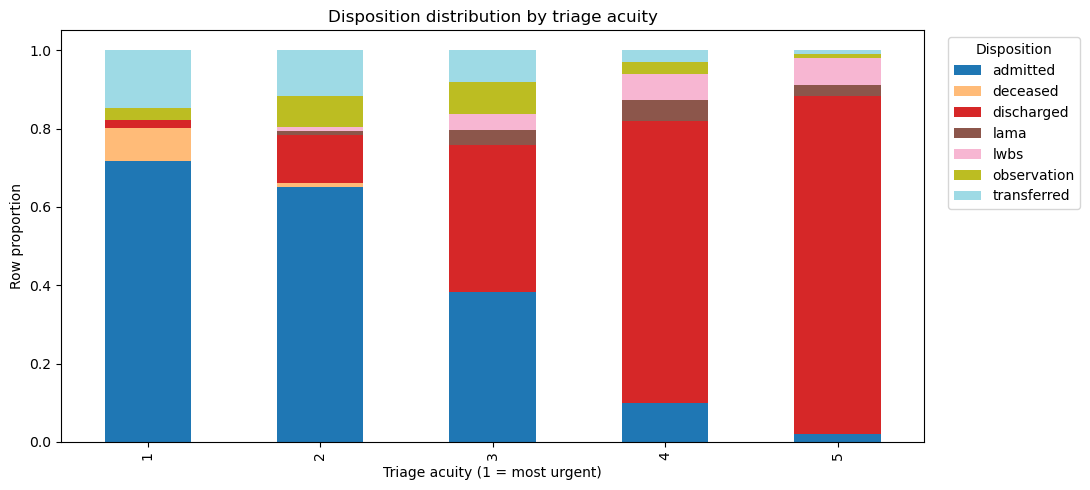

Triage acuity vs ED length of stay


,count,median,mean,q25,q75,p90
triage_acuity,,,,,,
1,3222,7.960,7.960,5.910,9.950,11.730
2,13439,6.020,6.040,4.350,7.740,9.220
3,28921,3.990,3.980,2.960,4.990,5.900
4,23020,2.000,2.010,1.320,2.660,3.270
5,11398,1.000,1.010,0.670,1.340,1.650


/var/folders/8h/0clzrwxd0zld2llysxzdtfzm0000gn/T/ipykernel_7228/3556294109.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(plot_df[TARGET_COL].dropna().unique()), showfliers=False)


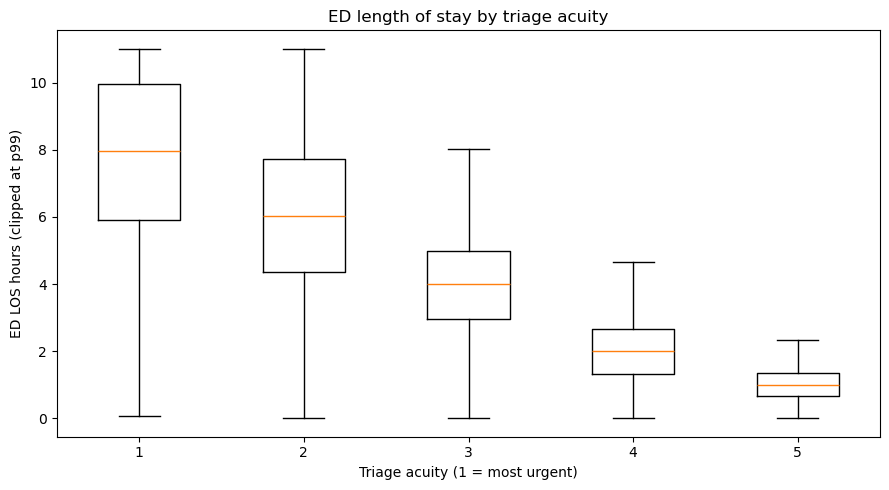

,low_acuity_4_5_cases,low_acuity_with_severe_downstream_proxy,rate_among_low_acuity
0,34418,3283,0.095


,patient_id,triage_acuity,disposition,ed_los_hours,chief_complaint_raw,news2_score,spo2,gcs_total
13,TG-RJC7LSWWP,4,admitted,2.250,ear pain with fever,1,100.000,15
37,TG-G80L23F7L,4,transferred,0.770,"minor skin rash, constant",0,96.700,15
40,TG-RELFNCVUM,5,transferred,1.460,inhaler technique question in known patient,0,97.800,15
61,TG-GZOYMVPT3,4,admitted,2.660,non-bloody diarrhoea with fever,2,97.000,15
69,TG-O5JS7HVHV,4,admitted,3.080,vaginal bleeding light with vomiting,1,96.300,15
164,TG-NZOK25VOB,4,transferred,2.960,diabetes management question with vomiting,1,100.000,15
221,TG-U2N6GJF1R,4,admitted,2.060,"mild low back pain, constant",1,99.200,15
239,TG-AUBGA0TZD,4,admitted,3.560,"uncomplicated UTI symptoms, onset today",0,95.500,15
241,TG-4PO7JHYN4,4,transferred,2.270,mild contact dermatitis，worsening over hours,1,99.500,15
243,TG-SC1ZQYQG3,4,admitted,1.390,"hand paraesthesia, onset today",2,100.000,15


Interpretation: these outcome variables are post-triage retrospective signals only. They are excluded from preprocessing feature matrices and cannot prove true clinical under-triage without chart review.


In [20]:
# Retrospective analysis only: outcome columns are not allowed in model features.
if {TARGET_COL, "disposition"}.issubset(train_eda.columns):
    disposition_counts = pd.crosstab(train_eda[TARGET_COL], train_eda["disposition"], margins=True)
    disposition_pct = pd.crosstab(train_eda[TARGET_COL], train_eda["disposition"], normalize="index").round(3)
    print("Triage acuity vs disposition counts")
    display(disposition_counts)
    print("Triage acuity vs disposition row percentages")
    display(disposition_pct)

    ax = disposition_pct.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab20")
    ax.set_title("Disposition distribution by triage acuity")
    ax.set_xlabel("Triage acuity (1 = most urgent)")
    ax.set_ylabel("Row proportion")
    ax.legend(title="Disposition", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

if {TARGET_COL, "ed_los_hours"}.issubset(train_eda.columns):
    los_summary = train_eda.groupby(TARGET_COL)["ed_los_hours"].agg(
        count="count",
        median="median",
        mean="mean",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    ).round(2)
    print("Triage acuity vs ED length of stay")
    display(los_summary)

    clipped_los = train_eda["ed_los_hours"].clip(upper=train_eda["ed_los_hours"].quantile(0.99))
    plot_df = train_eda.assign(ed_los_hours_clipped=clipped_los)
    data = [plot_df.loc[plot_df[TARGET_COL].eq(level), "ed_los_hours_clipped"].dropna() for level in sorted(plot_df[TARGET_COL].dropna().unique())]
    plt.figure(figsize=(9, 5))
    plt.boxplot(data, labels=sorted(plot_df[TARGET_COL].dropna().unique()), showfliers=False)
    plt.title("ED length of stay by triage acuity")
    plt.xlabel("Triage acuity (1 = most urgent)")
    plt.ylabel("ED LOS hours (clipped at p99)")
    plt.tight_layout()
    plt.show()

severe_disposition_proxy = pd.Series(False, index=train_eda.index)
if "disposition" in train_eda.columns:
    disposition_text = train_eda["disposition"].astype(str).str.lower().str.replace(" ", "_", regex=False)
    severe_disposition_proxy = disposition_text.str.contains("icu|critical|death|expire|operating|transfer|admit", regex=True, na=False)

long_los_proxy = pd.Series(False, index=train_eda.index)
if "ed_los_hours" in train_eda.columns:
    long_los_proxy = train_eda["ed_los_hours"].ge(train_eda["ed_los_hours"].quantile(0.95))

low_acuity_mask = train_eda[TARGET_COL].isin([4, 5])
severe_downstream_proxy = severe_disposition_proxy | long_los_proxy
low_acuity_severe_proxy = low_acuity_mask & severe_downstream_proxy

low_acuity_proxy_summary = pd.DataFrame({
    "low_acuity_4_5_cases": [int(low_acuity_mask.sum())],
    "low_acuity_with_severe_downstream_proxy": [int(low_acuity_severe_proxy.sum())],
    "rate_among_low_acuity": [low_acuity_severe_proxy.sum() / max(low_acuity_mask.sum(), 1)],
})
display(low_acuity_proxy_summary)

case_cols = [col for col in [ID_COL, TARGET_COL, "disposition", "ed_los_hours", "chief_complaint_raw", "news2_score", "spo2", "gcs_total"] if col in train_eda.columns]
display(train_eda.loc[low_acuity_severe_proxy, case_cols].head(20))

print("Interpretation: these outcome variables are post-triage retrospective signals only. They are excluded from preprocessing feature matrices and cannot prove true clinical under-triage without chart review.")

## 5.1 Preprocessing And Feature Engineering Functions

Define the reusable preprocessing and feature engineering logic. The functions copy input data before modifying it, avoid row deletion, apply the same logic to train and test, and skip source-dependent features defensively when a source column is unavailable.

Feature engineering is performed here, not as a separate later step. It includes derived vital-sign features, clinical risk flags, history aggregates, complaint text cleaning, red-flag keyword indicators, and missingness/invalid-value indicators.


In [21]:
def _clean_complaint_text(value):
    if pd.isna(value):
        return ""
    text = str(value).lower()
    text = re.sub(r"[^a-z0-9\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_invalid_values(df):
    """Convert clinically impossible values to NaN and add explicit invalid indicators."""
    df = df.copy()

    invalid_bounds = {
        "pain_score": (0, 10),
        "gcs_total": (3, 15),
        "spo2": (0, 100),
        "temperature_c": (30, 45),
        "heart_rate": (20, 250),
        "respiratory_rate": (3, 80),
        "systolic_bp": (40, 300),
        "diastolic_bp": (20, 200),
    }

    for col, (lower, upper) in invalid_bounds.items():
        invalid_col = f"{col}_invalid"
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce")
            invalid_mask = values.notna() & ((values < lower) | (values > upper))
            df[invalid_col] = invalid_mask.astype(int)
            df[col] = values.mask(invalid_mask, np.nan)
        else:
            df[invalid_col] = 0

    if {"systolic_bp", "diastolic_bp"}.issubset(df.columns):
        df["bp_inconsistent"] = (
            df["systolic_bp"].notna()
            & df["diastolic_bp"].notna()
            & (df["systolic_bp"] < df["diastolic_bp"])
        ).astype(int)
    else:
        df["bp_inconsistent"] = 0

    return df


def add_missing_indicators(df):
    """Create missingness indicators for clinical variables and a core vital missing count."""
    df = df.copy()

    for col in KEY_CLINICAL_COLS:
        if col in df.columns:
            df[f"{col}_missing"] = df[col].isna().astype(int)

    vital_indicator_cols = [f"{col}_missing" for col in CORE_VITAL_COLS if f"{col}_missing" in df.columns]
    df["missing_vital_count"] = df[vital_indicator_cols].sum(axis=1) if vital_indicator_cols else 0

    return df


def add_clinical_features(df):
    """Add derived vital features and interpretable clinical risk flags."""
    df = df.copy()

    if "pain_score" in df.columns:
        df["pain_score_clean"] = df["pain_score"]

    if {"systolic_bp", "diastolic_bp"}.issubset(df.columns):
        df["pulse_pressure"] = df["systolic_bp"] - df["diastolic_bp"]
        df.loc[df["bp_inconsistent"].eq(1), "pulse_pressure"] = np.nan
        df["mean_arterial_pressure"] = df["diastolic_bp"] + df["pulse_pressure"] / 3
        df.loc[df["bp_inconsistent"].eq(1), "mean_arterial_pressure"] = np.nan

    if {"heart_rate", "systolic_bp"}.issubset(df.columns):
        systolic_nonzero = df["systolic_bp"].replace(0, np.nan)
        df["shock_index"] = df["heart_rate"] / systolic_nonzero

    flag_rules = {
        "high_news2": ("news2_score", lambda s: s >= 5),
        "low_gcs": ("gcs_total", lambda s: s < 15),
        "very_low_gcs": ("gcs_total", lambda s: s <= 8),
        "low_spo2": ("spo2", lambda s: s < 94),
        "very_low_spo2": ("spo2", lambda s: s < 90),
        "tachypnea": ("respiratory_rate", lambda s: s >= 22),
        "fever": ("temperature_c", lambda s: s >= 38),
        "severe_pain": ("pain_score_clean", lambda s: s >= 8),
        "hypotension": ("systolic_bp", lambda s: s < 90),
    }

    for flag, (source_col, rule) in flag_rules.items():
        if source_col in df.columns:
            df[flag] = rule(df[source_col]).fillna(False).astype(int)

    if "mental_status_triage" in df.columns:
        altered_values = {"confused", "drowsy", "unresponsive", "agitated", "altered"}
        df["altered_mental_status_flag"] = df["mental_status_triage"].astype(str).str.lower().isin(altered_values).astype(int)
    else:
        df["altered_mental_status_flag"] = 0

    return df


def add_history_features(df):
    """Fill binary history flags and add summary history features."""
    df = df.copy()

    hx_cols = [col for col in df.columns if col.startswith("hx_")]
    if hx_cols:
        df[hx_cols] = df[hx_cols].fillna(0)
        df["comorbidity_count"] = df[hx_cols].sum(axis=1)
    else:
        df["comorbidity_count"] = 0

    high_risk_history_cols = [
        "hx_copd",
        "hx_heart_failure",
        "hx_ckd",
        "hx_immunosuppressed",
        "hx_coagulopathy",
        "hx_pregnant",
        "hx_coronary_artery_disease",
        "hx_stroke_prior",
        "hx_malignancy",
    ]
    available_high_risk_cols = [col for col in high_risk_history_cols if col in df.columns]
    if available_high_risk_cols:
        df["high_risk_history_flag"] = (df[available_high_risk_cols].fillna(0).eq(1).any(axis=1)).astype(int)
    else:
        df["high_risk_history_flag"] = 0

    return df


def clean_text_features(df):
    """Clean complaint text and add simple red-flag keyword indicators."""
    df = df.copy()

    if "chief_complaint_raw" not in df.columns:
        df["chief_complaint_raw"] = np.nan

    raw = df["chief_complaint_raw"]
    df["chief_complaint_missing"] = raw.isna().astype(int)
    df["chief_complaint_raw_clean"] = raw.map(_clean_complaint_text)
    df["chief_complaint_char_len"] = raw.fillna("").astype(str).str.len()
    df["chief_complaint_word_count"] = df["chief_complaint_raw_clean"].str.split().str.len()

    redflag_patterns = {
        "complaint_redflag_chest_pain": r"\b(chest pain|chest pressure|chest tightness)\b",
        "complaint_redflag_shortness_of_breath": r"\b(shortness of breath|sob|dyspnea|breathless)\b",
        "complaint_redflag_syncope": r"\b(syncope|faint|collapse|passed out)\b",
        "complaint_redflag_stroke_like": r"\b(stroke|facial droop|slurred speech|aphasia|one sided weakness|weakness)\b",
        "complaint_redflag_trauma": r"\b(trauma|fall|fracture|crash|assault|injury)\b",
        "complaint_redflag_bleeding": r"\b(bleeding|hemorrhage|haemorrhage|hematemesis|melena)\b",
        "complaint_redflag_pregnancy": r"\b(pregnan|labor|vaginal bleeding|ectopic)\b",
        "complaint_redflag_severe_headache": r"\b(thunderclap|worst headache|severe headache)\b",
    }
    for flag, pattern in redflag_patterns.items():
        df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)

    return df


def prepare_features(main_df, complaints_df, history_df, is_train=True):
    """Merge raw inputs and apply identical non-model preprocessing to train/test rows."""
    df = main_df.copy()

    df = df.merge(complaints_df.copy(), on=ID_COL, how="left", suffixes=("", "_complaints"))

    complaint_system_suffix = "chief_complaint_system_complaints"
    if complaint_system_suffix in df.columns:
        if "chief_complaint_system" in df.columns:
            both_present = df["chief_complaint_system"].notna() & df[complaint_system_suffix].notna()
            inconsistent = both_present & (df["chief_complaint_system"] != df[complaint_system_suffix])
            if inconsistent.any():
                print(
                    f"Warning: {int(inconsistent.sum())} rows have inconsistent chief_complaint_system values; "
                    "using main table first, then complaint table."
                )
            df["chief_complaint_system"] = df["chief_complaint_system"].combine_first(df[complaint_system_suffix])
            df = df.drop(columns=[complaint_system_suffix])
        else:
            df = df.rename(columns={complaint_system_suffix: "chief_complaint_system"})

    df = df.merge(history_df.copy(), on=ID_COL, how="left")

    df = clean_invalid_values(df)
    df = add_missing_indicators(df)
    df = add_clinical_features(df)
    df = add_history_features(df)
    df = clean_text_features(df)

    leakage_to_drop = [col for col in LEAKAGE_COLS if col in df.columns]
    if leakage_to_drop:
        df = df.drop(columns=leakage_to_drop)

    if not is_train and TARGET_COL in df.columns:
        df = df.drop(columns=[TARGET_COL])

    return df


## 5.2 Apply Preprocessing And Feature Engineering To Train/Test

Merge raw inputs by `patient_id`, remove post-triage leakage fields, clean invalid clinical values, create missingness and invalid-value indicators, engineer clinical risk flags, add patient history, and clean chief complaint text.


In [22]:
train_processed = prepare_features(train, chief_complaints, patient_history, is_train=True)
test_processed = prepare_features(test, chief_complaints, patient_history, is_train=False)

print(f"train_processed shape: {train_processed.shape}")
print(f"test_processed shape: {test_processed.shape}")

/var/folders/8h/0clzrwxd0zld2llysxzdtfzm0000gn/T/ipykernel_7228/4191147167.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)
/var/folders/8h/0clzrwxd0zld2llysxzdtfzm0000gn/T/ipykernel_7228/4191147167.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)
/var/folders/8h/0clzrwxd0zld2llysxzdtfzm0000gn/T/ipykernel_7228/4191147167.py:158: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[flag] = df["chief_complaint_raw_clean"].str.contains(pattern, regex=True, na=False).astype(int)
/var/folders/8h/0clzrwxd0zld2llysxzdtfzm0000gn/T/

train_processed shape: (80000, 108)
test_processed shape: (20000, 107)


## 5.3 Feature Engineering Summary

The table below makes the feature engineering step explicit. These engineered fields are created by the preprocessing functions and are available in `train_processed` / `test_processed` for modeling.


In [23]:
feature_engineering_summary = pd.DataFrame(
    [
        {
            "feature_group": "Derived vital signs",
            "examples": "mean_arterial_pressure, pulse_pressure, shock_index",
            "purpose": "Capture circulation and hemodynamic stress beyond raw blood pressure and heart rate.",
        },
        {
            "feature_group": "Clinical risk flags",
            "examples": "high_news2, low_gcs, very_low_spo2, tachypnea, fever, severe_pain, hypotension",
            "purpose": "Represent clinically interpretable high-risk rules available at triage.",
        },
        {
            "feature_group": "Mental status flag",
            "examples": "altered_mental_status_flag",
            "purpose": "Convert triage mental status categories into a binary acute neurologic-risk signal.",
        },
        {
            "feature_group": "History aggregates",
            "examples": "comorbidity_count, high_risk_history_flag",
            "purpose": "Summarize chronic disease burden and high-risk prior conditions.",
        },
        {
            "feature_group": "Complaint text features",
            "examples": "chief_complaint_raw_clean, chief_complaint_char_len, chief_complaint_word_count",
            "purpose": "Clean chief complaint text and add simple text-length descriptors.",
        },
        {
            "feature_group": "Complaint red flags",
            "examples": "complaint_redflag_chest_pain, complaint_redflag_stroke_like, complaint_redflag_trauma",
            "purpose": "Add clinically interpretable keyword indicators from chief complaint text.",
        },
        {
            "feature_group": "Data quality flags",
            "examples": "*_missing, *_invalid, missing_vital_count, bp_inconsistent",
            "purpose": "Preserve information about measurement absence, invalid values, and inconsistent blood pressure values.",
        },
    ]
)
display(feature_engineering_summary)


,feature_group,examples,purpose
0,Derived vital signs,"mean_arterial_pressure, pulse_pressure, shock_...",Capture circulation and hemodynamic stress bey...
1,Clinical risk flags,"high_news2, low_gcs, very_low_spo2, tachypnea,...",Represent clinically interpretable high-risk r...
2,Mental status flag,altered_mental_status_flag,Convert triage mental status categories into a...
3,History aggregates,"comorbidity_count, high_risk_history_flag",Summarize chronic disease burden and high-risk...
4,Complaint text features,"chief_complaint_raw_clean, chief_complaint_cha...",Clean chief complaint text and add simple text...
5,Complaint red flags,"complaint_redflag_chest_pain, complaint_redfla...",Add clinically interpretable keyword indicator...
6,Data quality flags,"*_missing, *_invalid, missing_vital_count, bp_...",Preserve information about measurement absence...


## 5.4 Validate Processed Outputs

Validate the processed handoff files before modeling: row IDs remain unique, target is present only in train, leakage columns are excluded, and train/test feature columns are aligned.



In [24]:
assert train_processed[ID_COL].is_unique, "train_processed contains duplicate patient_id values"
assert test_processed[ID_COL].is_unique, "test_processed contains duplicate patient_id values"
assert TARGET_COL in train_processed.columns, "train_processed must contain triage_acuity"
assert TARGET_COL not in test_processed.columns, "test_processed must not contain triage_acuity"
assert ID_COL in train_processed.columns and ID_COL in test_processed.columns, "patient_id must be preserved"
assert not set(LEAKAGE_COLS).intersection(train_processed.columns), "Leakage columns found in train_processed"
assert not set(LEAKAGE_COLS).intersection(test_processed.columns), "Leakage columns found in test_processed"

train_feature_cols = set(train_processed.columns) - {TARGET_COL}
test_feature_cols = set(test_processed.columns)
train_not_test = sorted(train_feature_cols - test_feature_cols)
test_not_train = sorted(test_feature_cols - train_feature_cols)

assert not train_not_test, f"Feature columns in train but not test: {train_not_test}"
assert not test_not_train, f"Feature columns in test but not train: {test_not_train}"

shape_summary = pd.DataFrame(
    {
        "dataset": ["train_raw", "test_raw", "train_processed", "test_processed"],
        "rows": [len(train), len(test), len(train_processed), len(test_processed)],
        "columns": [train.shape[1], test.shape[1], train_processed.shape[1], test_processed.shape[1]],
    }
)
display(shape_summary)

print("Columns in train_processed but not test_processed, excluding triage_acuity:", train_not_test)
print("Columns in test_processed but not train_processed:", test_not_train)

,dataset,rows,columns
0,train_raw,80000,40
1,test_raw,20000,37
2,train_processed,80000,108
3,test_processed,20000,107


Columns in train_processed but not test_processed, excluding triage_acuity: []
Columns in test_processed but not train_processed: []


## 6. Train/Test Drift Summary

Compare processed train and test distributions. These checks are still EDA, not model training. The goal is to identify major drift, unseen categorical levels, or missingness shifts that could affect leaderboard or deployment performance.


In [25]:
missing_drift_cols = [col for col in KEY_CLINICAL_COLS if col in train_processed.columns and col in test_processed.columns]
missing_drift_summary = pd.DataFrame(
    {
        "column": missing_drift_cols,
        "train_missing_rate": [train_processed[col].isna().mean() for col in missing_drift_cols],
        "test_missing_rate": [test_processed[col].isna().mean() for col in missing_drift_cols],
    }
)
missing_drift_summary["absolute_difference"] = (
    missing_drift_summary["test_missing_rate"] - missing_drift_summary["train_missing_rate"]
).abs()
display(missing_drift_summary.sort_values("absolute_difference", ascending=False))

,column,train_missing_rate,test_missing_rate,absolute_difference
7,pain_score,0.139,0.146,0.006
0,systolic_bp,0.052,0.048,0.004
1,diastolic_bp,0.052,0.048,0.004
4,temperature_c,0.007,0.005,0.002
3,respiratory_rate,0.038,0.038,0.001
2,heart_rate,0.000,0.000,0.000
5,spo2,0.000,0.000,0.000
6,gcs_total,0.000,0.000,0.000
8,news2_score,0.000,0.000,0.000


In [26]:
def categorical_drift_summary(train_df, test_df, columns):
    rows = []
    for col in columns:
        if col not in train_df.columns or col not in test_df.columns:
            rows.append(
                {
                    "column": col,
                    "train_unique_levels": np.nan,
                    "test_unique_levels": np.nan,
                    "unseen_test_level_count": np.nan,
                    "unseen_test_levels_sample": "column missing",
                }
            )
            continue

        train_levels = set(train_df[col].fillna("__MISSING__").astype(str))
        test_levels = set(test_df[col].fillna("__MISSING__").astype(str))
        unseen = sorted(test_levels - train_levels)
        rows.append(
            {
                "column": col,
                "train_unique_levels": len(train_levels),
                "test_unique_levels": len(test_levels),
                "unseen_test_level_count": len(unseen),
                "unseen_test_levels_sample": ", ".join(unseen[:20]),
            }
        )
    return pd.DataFrame(rows)

categorical_drift = categorical_drift_summary(train_processed, test_processed, CATEGORICAL_DRIFT_COLS)
display(categorical_drift)

,column,train_unique_levels,test_unique_levels,unseen_test_level_count,unseen_test_levels_sample
0,site_id,5,5,0,
1,triage_nurse_id,50,50,0,
2,arrival_mode,6,6,0,
3,language,8,8,0,
4,insurance_type,5,5,0,
5,transport_origin,7,7,0,
6,pain_location,9,9,0,
7,mental_status_triage,5,5,0,
8,chief_complaint_system,14,14,0,


In [27]:
def numeric_drift_summary(train_df, test_df, columns):
    rows = []
    for col in columns:
        if col not in train_df.columns or col not in test_df.columns:
            rows.append({"column": col, "status": "column missing"})
            continue
        rows.append(
            {
                "column": col,
                "status": "ok",
                "train_mean": train_df[col].mean(),
                "test_mean": test_df[col].mean(),
                "train_median": train_df[col].median(),
                "test_median": test_df[col].median(),
                "train_std": train_df[col].std(),
                "test_std": test_df[col].std(),
                "train_p05": train_df[col].quantile(0.05),
                "test_p05": test_df[col].quantile(0.05),
                "train_p95": train_df[col].quantile(0.95),
                "test_p95": test_df[col].quantile(0.95),
            }
        )
    return pd.DataFrame(rows)

numeric_drift = numeric_drift_summary(train_processed, test_processed, NUMERIC_DRIFT_COLS)
display(numeric_drift)

,column,status,train_mean,test_mean,train_median,test_median,train_std,test_std,train_p05,test_p05,train_p95,test_p95
0,age,ok,48.544,48.295,48.000,48.000,24.188,24.078,10.000,10.000,89.000,89.000
1,systolic_bp,ok,121.613,121.590,123.100,123.200,24.222,24.418,79.000,78.700,158.900,159.415
2,diastolic_bp,ok,74.452,74.578,75.300,75.600,14.286,14.319,49.100,49.000,96.300,96.400
3,heart_rate,ok,91.859,91.866,89.600,89.700,19.489,19.486,64.100,63.900,127.400,127.400
4,respiratory_rate,ok,18.334,18.353,17.300,17.300,4.647,4.616,12.700,12.800,27.900,27.900
5,temperature_c,ok,37.631,37.630,37.500,37.500,0.857,0.853,36.400,36.400,39.200,39.200
6,spo2,ok,95.794,95.795,97.000,97.000,4.307,4.279,87.000,87.100,100.000,100.000
7,gcs_total,ok,14.152,14.170,15.000,15.000,2.146,2.106,9.000,9.000,15.000,15.000
8,pain_score_clean,ok,5.398,5.417,5.000,5.000,2.722,2.714,1.000,1.000,10.000,10.000
9,news2_score,ok,3.427,3.434,2.000,2.000,4.259,4.251,0.000,0.000,13.000,13.000


## 7. Save Processed Files

Write the processed train/test feature files and preprocessing reports. These files are the modeling handoff and can be regenerated from the raw inputs by rerunning the preprocessing section.


In [28]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_processed_path = PROCESSED_DIR / "train_processed.csv"
test_processed_path = PROCESSED_DIR / "test_processed.csv"
feature_report_path = PROCESSED_DIR / "feature_report.csv"
legacy_feature_report_path = PROCESSED_DIR / "preprocessing_feature_report.csv"
preprocessing_report_path = PROCESSED_DIR / "preprocessing_report.csv"
eda_summary_path = PROCESSED_DIR / "eda_summary.md"

train_processed.to_csv(train_processed_path, index=False)
test_processed.to_csv(test_processed_path, index=False)

report_columns = sorted(set(train_processed.columns).union(test_processed.columns).union(LEAKAGE_COLS))
feature_report_rows = []
for col in report_columns:
    if col == TARGET_COL:
        role = "target"
        source = "target"
    elif col == ID_COL:
        role = "row_alignment_id_drop_before_modeling"
        source = "identifier"
    elif col in LEAKAGE_COLS:
        role = "excluded_post_triage_outcome"
        source = "outcome"
    elif col.endswith("_invalid") or col == "bp_inconsistent":
        role = "feature"
        source = "invalid_indicator"
    elif col.startswith("complaint_redflag_") or col.startswith("chief_complaint_"):
        role = "feature"
        source = "complaint"
    elif col.startswith("hx_") or col in ["comorbidity_count", "high_risk_history_flag"]:
        role = "feature"
        source = "history"
    elif col.endswith("_missing") or col == "missing_vital_count":
        role = "feature"
        source = "missing_indicator"
    elif col in CORE_VITAL_COLS + ["gcs_total", "pain_score", "news2_score", "shock_index", "pulse_pressure", "mean_arterial_pressure"]:
        role = "feature"
        source = "clinical"
    else:
        role = "feature"
        source = "structured"

    feature_report_rows.append(
        {
            "column_name": col,
            "dtype": str(train_processed[col].dtype) if col in train_processed.columns else str(test_processed[col].dtype) if col in test_processed.columns else "not_in_processed_outputs",
            "missing_rate_train_processed": train_processed[col].isna().mean() if col in train_processed.columns else np.nan,
            "missing_rate_test_processed": test_processed[col].isna().mean() if col in test_processed.columns else np.nan,
            "role": role,
            "source": source,
        }
    )

feature_report = pd.DataFrame(feature_report_rows)
feature_report.to_csv(feature_report_path, index=False)
feature_report.to_csv(legacy_feature_report_path, index=False)

invalid_indicator_cols = [
    "pain_score_invalid",
    "gcs_total_invalid",
    "spo2_invalid",
    "temperature_c_invalid",
    "heart_rate_invalid",
    "respiratory_rate_invalid",
    "systolic_bp_invalid",
    "diastolic_bp_invalid",
    "bp_inconsistent",
]
redflag_cols = [col for col in train_processed.columns if col.startswith("complaint_redflag_")]
train_feature_cols = set(train_processed.columns) - {TARGET_COL}
test_feature_cols = set(test_processed.columns)

preprocessing_report_rows = [
    {"metric": "train_processed_rows", "value": len(train_processed)},
    {"metric": "train_processed_columns", "value": train_processed.shape[1]},
    {"metric": "test_processed_rows", "value": len(test_processed)},
    {"metric": "test_processed_columns", "value": test_processed.shape[1]},
    {"metric": "feature_columns_equal_excluding_target", "value": train_feature_cols == test_feature_cols},
    {"metric": "target_column", "value": TARGET_COL},
    {"metric": "patient_id_preserved_for_alignment", "value": ID_COL in train_processed.columns and ID_COL in test_processed.columns},
    {"metric": "leakage_columns_excluded", "value": not set(LEAKAGE_COLS).intersection(train_processed.columns.union(test_processed.columns))},
    {"metric": "redflag_feature_count", "value": len(redflag_cols)},
]
for col in invalid_indicator_cols:
    preprocessing_report_rows.append({"metric": f"train_sum__{col}", "value": int(train_processed[col].sum()) if col in train_processed.columns else np.nan})
    preprocessing_report_rows.append({"metric": f"test_sum__{col}", "value": int(test_processed[col].sum()) if col in test_processed.columns else np.nan})

preprocessing_report = pd.DataFrame(preprocessing_report_rows)
preprocessing_report.to_csv(preprocessing_report_path, index=False)

high_acuity_rate = train_processed[TARGET_COL].isin([1, 2]).mean()
eda_summary = f"""# EDA and Preprocessing Summary

Generated outputs:
- `{train_processed_path}`
- `{test_processed_path}`
- `{feature_report_path}`
- `{preprocessing_report_path}`

Target:
- `{TARGET_COL}` is retained only in train.
- High acuity is acuity 1 or 2; observed train high-acuity rate is {high_acuity_rate:.2%}.

Leakage and row alignment:
- `patient_id` is preserved in processed outputs only for row alignment/submission bookkeeping.
- Modeling code must drop `patient_id` from the feature matrix.
- `disposition` and `ed_los_hours` are post-triage outcome variables and are excluded from processed model features.

Preprocessing additions:
- Invalid clinical values are set to missing and paired with explicit invalid indicators.
- Blood pressure inconsistency is flagged with `bp_inconsistent`.
- Chief complaint red-flag keyword features are included.
- `altered_mental_status_flag` is included.

Retrospective outcomes:
- Outcome analyses are post-hoc consistency checks only and must not be used for model training.
"""
eda_summary_path.write_text(eda_summary, encoding="utf-8")

display(
    pd.DataFrame(
        {
            "output": ["train_processed", "test_processed", "feature_report", "preprocessing_report", "eda_summary"],
            "path": [str(train_processed_path), str(test_processed_path), str(feature_report_path), str(preprocessing_report_path), str(eda_summary_path)],
            "rows": [len(train_processed), len(test_processed), len(feature_report), len(preprocessing_report), np.nan],
            "columns": [train_processed.shape[1], test_processed.shape[1], feature_report.shape[1], preprocessing_report.shape[1], np.nan],
        }
    )
)


,output,path,rows,columns
0,train_processed,data/processed/train_processed.csv,80000.000,108.000
1,test_processed,data/processed/test_processed.csv,20000.000,107.000
2,feature_report,data/processed/feature_report.csv,110.000,6.000
3,preprocessing_report,data/processed/preprocessing_report.csv,27.000,2.000
4,eda_summary,data/processed/eda_summary.md,NaN,NaN


## 8. Preprocessing Handoff Summary

The processed files are ready for modeling:

- Use `data/processed/train_processed.csv` and `data/processed/test_processed.csv` as the feature handoff files.
- `triage_acuity` is the target and is retained only in `train_processed.csv`.
- Drop `patient_id` before model fitting; keep it only for validation bookkeeping and submission alignment.
- Do not use `disposition` or `ed_los_hours` as model features.
- Compare clinically constrained models against full-feature models to check dependence on `triage_nurse_id`, `site_id`, dominant clinical rules, and complaint text.


## 9. Modeling Preparation From EDA

This section turns the EDA and preprocessing findings into a concrete modeling plan. It defines feature groups, ablation variants, risk checks, and validation strategy before fitting models.

The clinical objective is to predict `triage_acuity` from information available at triage time. Lower values indicate higher urgency, so downstream modeling prioritizes high-acuity recall and severe-undertriage reduction rather than accuracy alone.


In [29]:
HIGH_ACUITY_LABELS = {1, 2}
LOW_ACUITY_LABELS = {4, 5}


def pct(value):
    if pd.isna(value):
        return ""
    return f"{100 * value:.2f}%"


def high_acuity_rate(series):
    return series.isin(HIGH_ACUITY_LABELS).mean()


target_modeling_summary = (
    train_processed[TARGET_COL]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COL)
    .reset_index(name="count")
)
target_modeling_summary["percent"] = target_modeling_summary["count"].div(len(train_processed)).map(pct)

print(f"Processed train shape: {train_processed.shape}")
print(f"Processed test shape: {test_processed.shape}")
print(f"High-acuity rate (acuity 1/2): {pct(train_processed[TARGET_COL].isin(HIGH_ACUITY_LABELS).mean())}")
display(target_modeling_summary)


Processed train shape: (80000, 108)
Processed test shape: (20000, 107)
High-acuity rate (acuity 1/2): 20.83%


,triage_acuity,count,percent
0,1,3222,4.03%
1,2,13439,16.80%
2,3,28921,36.15%
3,4,23020,28.78%
4,5,11398,14.25%


### 9.1 Feature Groups For Ablation

The processed table is suitable for modeling, but feature groups should be compared rather than relying on one full-feature model. This helps identify whether predictions are driven by bedside clinical data, engineered clinical rules, patient history, complaint text, workflow context, or operational identifiers.


In [30]:
def existing_columns(columns, df):
    return [col for col in columns if col in df.columns]


def build_feature_groups(df):
    core_demographics = existing_columns(["age", "age_group", "sex", "weight_kg", "height_cm", "bmi"], df)
    core_vitals = existing_columns(
        [
            "systolic_bp",
            "diastolic_bp",
            "heart_rate",
            "respiratory_rate",
            "temperature_c",
            "spo2",
            "gcs_total",
            "mental_status_triage",
            "pain_score_clean",
        ],
        df,
    )
    derived_clinical = existing_columns(
        [
            "mean_arterial_pressure",
            "pulse_pressure",
            "shock_index",
            "news2_score",
            "high_news2",
            "low_gcs",
            "very_low_gcs",
            "low_spo2",
            "very_low_spo2",
            "tachypnea",
            "fever",
            "severe_pain",
            "hypotension",
            "altered_mental_status_flag",
        ],
        df,
    )
    history = [
        col
        for col in df.columns
        if col.startswith("hx_")
        or col
        in {
            "num_prior_ed_visits_12m",
            "num_prior_admissions_12m",
            "num_active_medications",
            "num_comorbidities",
            "comorbidity_count",
            "high_risk_history_flag",
        }
    ]
    complaint_structured = existing_columns(
        [
            "chief_complaint_system",
            "pain_location",
            "chief_complaint_char_len",
            "chief_complaint_word_count",
            "chief_complaint_missing",
        ],
        df,
    )
    complaint_redflags = [col for col in df.columns if col.startswith("complaint_redflag_")]
    complaint_text = existing_columns(["chief_complaint_raw_clean"], df)
    workflow_context = existing_columns(
        [
            "arrival_mode",
            "arrival_hour",
            "arrival_day",
            "arrival_month",
            "arrival_season",
            "shift",
            "transport_origin",
            "language",
            "insurance_type",
        ],
        df,
    )
    operational_identifiers = existing_columns(["site_id", "triage_nurse_id"], df)
    quality_flags = [
        col
        for col in df.columns
        if col.endswith("_missing") or col.endswith("_invalid") or col in {"missing_vital_count", "bp_inconsistent"}
    ]

    return {
        "core_demographics": core_demographics,
        "core_vitals": core_vitals,
        "derived_clinical": derived_clinical,
        "history": history,
        "complaint_structured": complaint_structured,
        "complaint_redflags": complaint_redflags,
        "complaint_text": complaint_text,
        "workflow_context": workflow_context,
        "operational_identifiers": operational_identifiers,
        "quality_flags": quality_flags,
    }


feature_groups = build_feature_groups(train_processed)
feature_group_inventory = pd.DataFrame(
    [
        {
            "feature_group": group,
            "n_features": len(columns),
            "example_columns": ", ".join(columns[:8]),
        }
        for group, columns in feature_groups.items()
    ]
)

selected_feature_columns = set().union(*[set(cols) for cols in feature_groups.values()])
excluded_from_ablation = sorted((set(train_processed.columns) - {ID_COL, TARGET_COL}) - selected_feature_columns)

print("Columns intentionally left outside ablation groups:", excluded_from_ablation)
display(feature_group_inventory)




Columns intentionally left outside ablation groups: ['chief_complaint_raw', 'pain_score']


,feature_group,n_features,example_columns
0,core_demographics,6,"age, age_group, sex, weight_kg, height_cm, bmi"
1,core_vitals,9,"systolic_bp, diastolic_bp, heart_rate, respira..."
2,derived_clinical,14,"mean_arterial_pressure, pulse_pressure, shock_..."
3,history,31,"num_prior_ed_visits_12m, num_prior_admissions_..."
4,complaint_structured,5,"chief_complaint_system, pain_location, chief_c..."
5,complaint_redflags,8,"complaint_redflag_chest_pain, complaint_redfla..."
6,complaint_text,1,chief_complaint_raw_clean
7,workflow_context,9,"arrival_mode, arrival_hour, arrival_day, arriv..."
8,operational_identifiers,2,"site_id, triage_nurse_id"
9,quality_flags,20,"pain_score_invalid, gcs_total_invalid, spo2_in..."


In [31]:
def count_features(group_names):
    selected = set()
    for group_name in group_names:
        selected.update(feature_groups[group_name])
    return len(selected)


ablation_rows = [
    {
        "variant": "core clinical",
        "included_groups": "core_demographics, core_vitals",
        "feature_count": count_features(["core_demographics", "core_vitals"]),
        "question_answered": "How much can bedside clinical data explain before engineered rules?",
    },
    {
        "variant": "core + derived clinical",
        "included_groups": "core_demographics, core_vitals, derived_clinical",
        "feature_count": count_features(["core_demographics", "core_vitals", "derived_clinical"]),
        "question_answered": "How much lift comes from NEWS2, shock index, and explicit risk flags?",
    },
    {
        "variant": "core + history",
        "included_groups": "core_demographics, core_vitals, history",
        "feature_count": count_features(["core_demographics", "core_vitals", "history"]),
        "question_answered": "Does baseline risk and comorbidity improve acuity prediction?",
    },
    {
        "variant": "core + complaint structured",
        "included_groups": "core_demographics, core_vitals, complaint_structured",
        "feature_count": count_features(["core_demographics", "core_vitals", "complaint_structured"]),
        "question_answered": "Does presenting complaint category add signal beyond vitals?",
    },
    {
        "variant": "core + complaint red flags",
        "included_groups": "core_demographics, core_vitals, complaint_structured, complaint_redflags",
        "feature_count": count_features(["core_demographics", "core_vitals", "complaint_structured", "complaint_redflags"]),
        "question_answered": "Do interpretable red-flag keywords add useful signal?",
    },
    {
        "variant": "core + complaint text",
        "included_groups": "core_demographics, core_vitals, complaint_structured, complaint_text",
        "feature_count": count_features(["core_demographics", "core_vitals", "complaint_structured", "complaint_text"]),
        "question_answered": "Does free-text complaint content help, and does it survive grouped validation?",
    },
    {
        "variant": "clinical + history + complaint",
        "included_groups": "core_demographics, core_vitals, derived_clinical, history, complaint_structured, complaint_redflags",
        "feature_count": count_features(
            ["core_demographics", "core_vitals", "derived_clinical", "history", "complaint_structured", "complaint_redflags"]
        ),
        "question_answered": "How strong is a clinically explainable model without raw text or operational IDs?",
    },
    {
        "variant": "full non-text structured",
        "included_groups": "all except complaint_text",
        "feature_count": count_features([group for group in feature_groups if group != "complaint_text"]),
        "question_answered": "Best structured feature set before adding TF-IDF text.",
    },
    {
        "variant": "full with complaint text",
        "included_groups": "all groups",
        "feature_count": count_features(list(feature_groups)),
        "question_answered": "Best candidate feature set; validate with GroupKFold by complaint template.",
    },
    {
        "variant": "full minus nurse/site",
        "included_groups": "all except operational_identifiers",
        "feature_count": count_features([group for group in feature_groups if group != "operational_identifiers"]),
        "question_answered": "Does performance depend on operational identifiers rather than patient state?",
    },
    {
        "variant": "full minus dominant rules",
        "included_groups": "all groups, excluding NEWS2 and GCS-derived flags",
        "feature_count": count_features(list(feature_groups))
        - len(existing_columns(["news2_score", "high_news2", "low_gcs", "very_low_gcs"], train_processed)),
        "question_answered": "Does the model still work without the strongest rule-like clinical signals?",
    },
]

ablation_design = pd.DataFrame(ablation_rows)
display(ablation_design)


,variant,included_groups,feature_count,question_answered
0,core clinical,"core_demographics, core_vitals",15,How much can bedside clinical data explain bef...
1,core + derived clinical,"core_demographics, core_vitals, derived_clinical",29,"How much lift comes from NEWS2, shock index, a..."
2,core + history,"core_demographics, core_vitals, history",46,Does baseline risk and comorbidity improve acu...
3,core + complaint structured,"core_demographics, core_vitals, complaint_stru...",20,Does presenting complaint category add signal ...
4,core + complaint red flags,"core_demographics, core_vitals, complaint_stru...",28,Do interpretable red-flag keywords add useful ...
5,core + complaint text,"core_demographics, core_vitals, complaint_stru...",21,"Does free-text complaint content help, and doe..."
6,clinical + history + complaint,"core_demographics, core_vitals, derived_clinic...",73,How strong is a clinically explainable model w...
7,full non-text structured,all except complaint_text,103,Best structured feature set before adding TF-I...
8,full with complaint text,all groups,104,Best candidate feature set; validate with Grou...
9,full minus nurse/site,all except operational_identifiers,102,Does performance depend on operational identif...


### 9.2 Modeling Risk Checks From EDA

Before training, review two high-risk patterns from EDA:

- Strong clinical-rule features may dominate model behavior.
- Repeated chief complaint templates may make text models look unrealistically strong under random validation.


In [32]:
clinical_signal_cols = [
    "high_news2",
    "low_gcs",
    "very_low_gcs",
    "low_spo2",
    "very_low_spo2",
    "tachypnea",
    "fever",
    "hypotension",
    "altered_mental_status_flag",
    "high_risk_history_flag",
    "severe_pain",
]

clinical_signal_rows = []
for col in clinical_signal_cols:
    if col not in train_processed.columns:
        continue
    positive = train_processed[col].eq(1)
    negative = train_processed[col].eq(0)
    clinical_signal_rows.append(
        {
            "feature": col,
            "positive_n": int(positive.sum()),
            "positive_pct": pct(positive.mean()),
            "positive_high_acuity_rate": pct(high_acuity_rate(train_processed.loc[positive, TARGET_COL])),
            "negative_high_acuity_rate": pct(high_acuity_rate(train_processed.loc[negative, TARGET_COL])),
            "positive_mean_acuity": round(train_processed.loc[positive, TARGET_COL].mean(), 3),
        }
    )

display(pd.DataFrame(clinical_signal_rows))


,feature,positive_n,positive_pct,positive_high_acuity_rate,negative_high_acuity_rate,positive_mean_acuity
0,high_news2,20517,25.65%,79.75%,0.50%,2.047
1,low_gcs,14723,18.40%,100.00%,2.97%,1.781
2,very_low_gcs,2401,3.00%,100.00%,18.38%,1.000
3,low_spo2,19131,23.91%,60.44%,8.38%,2.272
4,very_low_spo2,7530,9.41%,91.69%,13.46%,1.777
5,tachypnea,13272,16.59%,79.11%,9.23%,2.008
6,fever,24897,31.12%,52.08%,6.71%,2.431
7,hypotension,7893,9.87%,78.66%,14.50%,1.997
8,altered_mental_status_flag,33788,42.23%,45.15%,3.04%,2.639
9,high_risk_history_flag,65580,81.97%,22.71%,12.25%,3.286


In [33]:
complaint_col = "chief_complaint_raw_clean"
complaint_counts = train_processed[complaint_col].fillna("__MISSING__").astype(str).value_counts()
repeated_complaints = complaint_counts[complaint_counts > 1]

complaint_template_summary = pd.DataFrame(
    [
        {"item": "unique cleaned complaint templates", "value": len(complaint_counts)},
        {"item": "templates repeated more than once", "value": len(repeated_complaints)},
        {"item": "rows in repeated templates", "value": int(repeated_complaints.sum())},
        {"item": "percent rows in repeated templates", "value": pct(repeated_complaints.sum() / len(train_processed))},
        {"item": "top 10 template row share", "value": pct(complaint_counts.head(10).sum() / len(train_processed))},
    ]
)

template_purity_rows = []
for complaint, labels in train_processed.groupby(complaint_col)[TARGET_COL]:
    if len(labels) < 30:
        continue
    mode_counts = labels.value_counts(normalize=True)
    template_purity_rows.append(
        {
            "complaint_template": complaint,
            "n": len(labels),
            "mode_acuity": int(mode_counts.index[0]),
            "mode_share": pct(float(mode_counts.iloc[0])),
        }
    )

template_purity = pd.DataFrame(template_purity_rows).sort_values(["mode_share", "n"], ascending=[False, False]).head(15)

display(complaint_template_summary)
display(template_purity)


,item,value
0,unique cleaned complaint templates,4949
1,templates repeated more than once,4803
2,rows in repeated templates,79854
3,percent rows in repeated templates,99.82%
4,top 10 template row share,0.52%


,complaint_template,n,mode_acuity,mode_share
353,sti with systemic features in known patient,44,3,100.00%
277,new onset jaundice with vomiting,43,3,100.00%
18,acute stress reaction worsening with movement,41,3,100.00%
47,chest tightness with dyspnoea onset today,41,3,100.00%
131,electrolyte imbalance symptomatic worsening ov...,41,3,100.00%
132,electrolyte imbalance symptomatic worsening wi...,41,3,100.00%
139,exertional chest pain with associated nausea,41,3,100.00%
361,sudden visual blurring for 2 days,41,3,100.00%
45,cellulitis localised worsening with movement,40,3,100.00%
111,dyspnoea on exertion for 2 days,40,3,100.00%


### 9.3 Validation And Metrics For Modeling

Recommended validation design:

| Validation | Purpose | Risk |
|---|---|---|
| Stratified random split | Fast baseline and sanity check | May overestimate performance because complaint templates repeat |
| GroupKFold by `chief_complaint_raw_clean` | Stress-test complaint text/template generalization | Lower score is expected and more informative |
| Sensitivity without `triage_nurse_id` / `site_id` | Check dependence on operational practice patterns | Can reduce score if identifiers encode workflow shortcuts |

Metric priority:

- Primary clinical metrics: high-acuity recall and severe undertriage rate.
- Supporting metrics: macro F1, weighted F1, quadratic weighted kappa, MAE, and confusion matrix.
- Accuracy should be reported, but not used alone for model selection.

Implementation notes:

- Always exclude `patient_id` from the feature matrix.
- Use `triage_acuity` only as the target label.
- Keep `disposition` and `ed_los_hours` out of all training features.
- Encode categorical columns inside each ablation variant rather than pre-encoding the full table.
- If complaint text is included, validate with `GroupKFold` grouped by `chief_complaint_raw_clean`.


## 10. Modeling Experiments

This section compares Logistic Regression, LightGBM, XGBoost, and CatBoost. Logistic Regression first runs the full feature-ablation sweep; boosting models are evaluated on the strongest candidate feature sets. The initial random and grouped holdouts are kept as quick diagnostics.

Final model selection is then based on 5-fold `StratifiedGroupKFold` by `chief_complaint_raw_clean`, compact hyperparameter searches for the strongest model families, and a soft-voting ensemble of the top grouped-CV candidates. This gives error bars and avoids selecting a submission model from one lucky grouped split.


In [34]:
RANDOM_STATE = 42
VALIDATION_SIZE = 0.20
TEXT_MAX_FEATURES = 5000
DOMINANT_RULE_COLUMNS = ["news2_score", "high_news2", "low_gcs", "very_low_gcs"]

try:
    _ = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    OHE_KWARGS = {"handle_unknown": "ignore", "sparse_output": True}
except TypeError:
    OHE_KWARGS = {"handle_unknown": "ignore", "sparse": True}

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


### 10.1 Evaluation Metrics Function

The evaluation function reports ordinary classification metrics plus triage-specific safety metrics. The key clinical metric is high-acuity recall: among true acuity 1/2 patients, how many are predicted as 1/2. Severe undertriage is the high-risk failure mode: true acuity 1/2 predicted as 4/5.


In [35]:
def evaluate_triage_predictions(y_true, y_pred, labels=(1, 2, 3, 4, 5)):
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    y_pred = pd.Series(y_pred).astype(int).reset_index(drop=True)

    true_high = y_true.isin(HIGH_ACUITY_LABELS)
    pred_high = y_pred.isin(HIGH_ACUITY_LABELS)
    severe_undertriage = true_high & y_pred.isin(LOW_ACUITY_LABELS)
    any_undertriage = y_pred.gt(y_true)
    overtriage = y_pred.lt(y_true)

    high_recall = (true_high & pred_high).sum() / true_high.sum() if true_high.sum() else np.nan
    high_precision = (true_high & pred_high).sum() / pred_high.sum() if pred_high.sum() else np.nan
    severe_undertriage_rate = severe_undertriage.sum() / true_high.sum() if true_high.sum() else np.nan

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "mae": mean_absolute_error(y_true, y_pred),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "high_acuity_recall": high_recall,
        "high_acuity_precision": high_precision,
        "predicted_high_rate": pred_high.mean(),
        "severe_undertriage_rate": severe_undertriage_rate,
        "any_undertriage_rate": any_undertriage.mean(),
        "overtriage_rate": overtriage.mean(),
    }


def format_metric_table(df):
    metric_cols = [
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "mae",
        "qwk",
        "high_acuity_recall",
        "high_acuity_precision",
        "predicted_high_rate",
        "severe_undertriage_rate",
        "any_undertriage_rate",
        "overtriage_rate",
    ]
    formatted = df.copy()
    for col in metric_cols:
        if col in formatted.columns:
            formatted[col] = formatted[col].astype(float).round(4)
    return formatted


### 10.2 Validation Split Runners

The random split checks ordinary performance. The grouped split uses `StratifiedGroupKFold` with `chief_complaint_raw_clean` as the group, so the same complaint template does not appear in both training and validation. This is the key check for whether complaint text is inflating validation scores.


In [36]:
def get_random_holdout_indices(y, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE):
    indices = np.arange(len(y))
    train_idx, valid_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )
    return train_idx, valid_idx


def iter_stratified_group_folds(y, groups, n_splits=5, random_state=RANDOM_STATE):
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    indices = np.arange(len(y))
    yield from splitter.split(indices, y, groups)


def get_first_group_holdout_indices(y, groups, n_splits=5, random_state=RANDOM_STATE):
    return next(iter_stratified_group_folds(y, groups, n_splits=n_splits, random_state=random_state))


y_model = train_processed[TARGET_COL].astype(int)
random_train_idx, random_valid_idx = get_random_holdout_indices(y_model)
group_train_idx, group_valid_idx = get_first_group_holdout_indices(
    y_model,
    train_processed["chief_complaint_raw_clean"].fillna("__MISSING__").astype(str),
)

split_summary = pd.DataFrame(
    [
        {
            "split": "random_holdout",
            "train_rows": len(random_train_idx),
            "valid_rows": len(random_valid_idx),
            "valid_high_acuity_rate": pct(y_model.iloc[random_valid_idx].isin(HIGH_ACUITY_LABELS).mean()),
            "valid_unique_complaint_templates": train_processed.iloc[random_valid_idx]["chief_complaint_raw_clean"].nunique(),
        },
        {
            "split": "grouped_complaint_holdout",
            "train_rows": len(group_train_idx),
            "valid_rows": len(group_valid_idx),
            "valid_high_acuity_rate": pct(y_model.iloc[group_valid_idx].isin(HIGH_ACUITY_LABELS).mean()),
            "valid_unique_complaint_templates": train_processed.iloc[group_valid_idx]["chief_complaint_raw_clean"].nunique(),
        },
    ]
)
display(split_summary)


,split,train_rows,valid_rows,valid_high_acuity_rate,valid_unique_complaint_templates
0,random_holdout,64000,16000,20.82%,4302
1,grouped_complaint_holdout,64170,15830,21.61%,990


### 10.3 Logistic Regression Full Ablation Runner

Categorical variables are one-hot encoded, numeric variables are median-imputed and standardized, and complaint text uses TF-IDF when included. The same model configuration is used across ablations so differences mostly reflect feature groups rather than tuning choices.


In [37]:
def columns_for_groups(group_names, exclude_columns=None):
    selected = []
    seen = set()
    exclude_columns = set(exclude_columns or [])
    for group_name in group_names:
        for col in feature_groups[group_name]:
            if col not in seen and col not in exclude_columns:
                selected.append(col)
                seen.add(col)
    return selected


ablation_specs = [
    {
        "variant": "core clinical",
        "groups": ["core_demographics", "core_vitals"],
        "exclude": [],
    },
    {
        "variant": "core + derived clinical",
        "groups": ["core_demographics", "core_vitals", "derived_clinical"],
        "exclude": [],
    },
    {
        "variant": "core + history",
        "groups": ["core_demographics", "core_vitals", "history"],
        "exclude": [],
    },
    {
        "variant": "core + complaint structured",
        "groups": ["core_demographics", "core_vitals", "complaint_structured"],
        "exclude": [],
    },
    {
        "variant": "core + complaint red flags",
        "groups": ["core_demographics", "core_vitals", "complaint_structured", "complaint_redflags"],
        "exclude": [],
    },
    {
        "variant": "core + complaint text",
        "groups": ["core_demographics", "core_vitals", "complaint_structured", "complaint_text"],
        "exclude": [],
    },
    {
        "variant": "clinical + history + complaint",
        "groups": ["core_demographics", "core_vitals", "derived_clinical", "history", "complaint_structured", "complaint_redflags"],
        "exclude": [],
    },
    {
        "variant": "full non-text structured",
        "groups": [group for group in feature_groups if group != "complaint_text"],
        "exclude": [],
    },
    {
        "variant": "full with complaint text",
        "groups": list(feature_groups),
        "exclude": [],
    },
    {
        "variant": "full minus nurse/site",
        "groups": [group for group in feature_groups if group != "operational_identifiers"],
        "exclude": [],
    },
    {
        "variant": "full minus dominant rules",
        "groups": list(feature_groups),
        "exclude": DOMINANT_RULE_COLUMNS,
    },
]

for spec in ablation_specs:
    spec["columns"] = columns_for_groups(spec["groups"], spec["exclude"])
    spec["feature_count"] = len(spec["columns"])

ablation_spec_table = pd.DataFrame(
    [{"variant": spec["variant"], "feature_count": spec["feature_count"], "has_text": "chief_complaint_raw_clean" in spec["columns"]} for spec in ablation_specs]
)
display(ablation_spec_table)


,variant,feature_count,has_text
0,core clinical,15,False
1,core + derived clinical,29,False
2,core + history,46,False
3,core + complaint structured,20,False
4,core + complaint red flags,28,False
5,core + complaint text,21,True
6,clinical + history + complaint,73,False
7,full non-text structured,103,False
8,full with complaint text,104,True
9,full minus nurse/site,102,True


In [38]:
def make_logistic_pipeline(feature_columns):
    feature_columns = list(feature_columns)
    text_columns = [col for col in ["chief_complaint_raw_clean"] if col in feature_columns]
    structured_columns = [col for col in feature_columns if col not in text_columns]
    categorical_columns = train_processed[structured_columns].select_dtypes(include="object").columns.tolist()
    numeric_columns = [col for col in structured_columns if col not in categorical_columns]

    transformers = []
    if numeric_columns:
        transformers.append(
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler(with_mean=False)),
                    ]
                ),
                numeric_columns,
            )
        )
    if categorical_columns:
        transformers.append(
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(**OHE_KWARGS)),
                    ]
                ),
                categorical_columns,
            )
        )
    if text_columns:
        transformers.append(
            (
                "complaint_text",
                TfidfVectorizer(
                    min_df=3,
                    max_features=TEXT_MAX_FEATURES,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                ),
                text_columns[0],
            )
        )

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=1.0)
    classifier = LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        max_iter=500,
        C=1.0,
        random_state=RANDOM_STATE,
    )
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", classifier)])


def fit_evaluate_ablation(spec, train_idx, valid_idx, split_name):
    feature_columns = spec["columns"]
    X_train = train_processed.iloc[train_idx][feature_columns]
    X_valid = train_processed.iloc[valid_idx][feature_columns]
    y_train = y_model.iloc[train_idx]
    y_valid = y_model.iloc[valid_idx]

    pipeline = make_logistic_pipeline(feature_columns)
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_valid)

    metrics = evaluate_triage_predictions(y_valid, pred)
    return {
        "model": "Logistic Regression",
        "variant": spec["variant"],
        "split": split_name,
        "feature_count": spec["feature_count"],
        "has_text": "chief_complaint_raw_clean" in feature_columns,
        **metrics,
    }



### 10.4 Logistic Regression Ablations: Random Split vs Grouped Complaint Split

The table below compares every planned ablation under both validation strategies. The grouped split is the more conservative estimate for models using complaint text because it prevents identical complaint templates from appearing in both train and validation.


In [39]:
ablation_results = []
for spec in ablation_specs:
    ablation_results.append(fit_evaluate_ablation(spec, random_train_idx, random_valid_idx, "random"))
    ablation_results.append(fit_evaluate_ablation(spec, group_train_idx, group_valid_idx, "grouped_complaint"))

ablation_results_df = pd.DataFrame(ablation_results)
ablation_results_display = format_metric_table(
    ablation_results_df.sort_values(["split", "high_acuity_recall", "severe_undertriage_rate", "macro_f1"], ascending=[True, False, True, False])
)
display(ablation_results_display)


,model,variant,split,feature_count,has_text,accuracy,macro_f1,weighted_f1,mae,qwk,high_acuity_recall,high_acuity_precision,predicted_high_rate,severe_undertriage_rate,any_undertriage_rate,overtriage_rate
11,Logistic Regression,core + complaint text,grouped_complaint,21,True,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.216,0.000,0.000,0.000
21,Logistic Regression,full minus dominant rules,grouped_complaint,100,True,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.216,0.000,0.000,0.000
19,Logistic Regression,full minus nurse/site,grouped_complaint,102,True,0.999,0.997,0.999,0.001,0.999,0.999,1.000,0.216,0.000,0.001,0.000
17,Logistic Regression,full with complaint text,grouped_complaint,104,True,0.998,0.996,0.998,0.002,0.999,0.998,1.000,0.216,0.000,0.002,0.000
15,Logistic Regression,full non-text structured,grouped_complaint,103,False,0.814,0.832,0.813,0.190,0.913,0.937,0.961,0.211,0.000,0.103,0.083
13,Logistic Regression,clinical + history + complaint,grouped_complaint,73,False,0.798,0.820,0.798,0.204,0.908,0.934,0.957,0.211,0.000,0.115,0.087
3,Logistic Regression,core + derived clinical,grouped_complaint,29,False,0.766,0.795,0.767,0.238,0.892,0.927,0.960,0.209,0.000,0.141,0.093
9,Logistic Regression,core + complaint red flags,grouped_complaint,28,False,0.769,0.794,0.767,0.237,0.891,0.922,0.972,0.205,0.001,0.126,0.105
5,Logistic Regression,core + history,grouped_complaint,46,False,0.759,0.789,0.754,0.246,0.888,0.922,0.972,0.205,0.002,0.123,0.119
1,Logistic Regression,core clinical,grouped_complaint,15,False,0.746,0.776,0.741,0.261,0.881,0.915,0.981,0.202,0.001,0.132,0.123


### 10.5 Random vs Group Split Comparison

This view shows how much each ablation changes when moving from random validation to complaint-template grouped validation. A large random-minus-group gap, especially for text variants, suggests that random validation may be inflated by repeated complaint templates.


In [40]:
comparison_metrics = [
    "accuracy",
    "macro_f1",
    "qwk",
    "high_acuity_recall",
    "high_acuity_precision",
    "severe_undertriage_rate",
]

random_results = ablation_results_df[ablation_results_df["split"].eq("random")].set_index("variant")
group_results = ablation_results_df[ablation_results_df["split"].eq("grouped_complaint")].set_index("variant")
validation_gap = random_results[comparison_metrics].subtract(group_results[comparison_metrics], fill_value=np.nan)
validation_gap = validation_gap.add_prefix("random_minus_group_").reset_index()
validation_gap = validation_gap.merge(
    ablation_spec_table[["variant", "has_text"]],
    on="variant",
    how="left",
)
validation_gap_display = format_metric_table(validation_gap)
display(validation_gap_display.sort_values("random_minus_group_macro_f1", ascending=False))


,variant,random_minus_group_accuracy,random_minus_group_macro_f1,random_minus_group_qwk,random_minus_group_high_acuity_recall,random_minus_group_high_acuity_precision,random_minus_group_severe_undertriage_rate,has_text
2,core + history,0.016,0.011,0.003,-0.015,-0.004,-0.001,False
0,core clinical,0.012,0.009,0.001,-0.009,-0.003,0.001,False
3,core + complaint structured,0.009,0.008,-0.001,-0.007,-0.006,0.000,False
7,full non-text structured,0.007,0.007,-0.001,-0.010,-0.002,-0.000,False
1,core + derived clinical,0.006,0.005,-0.002,-0.007,-0.005,0.000,False
6,clinical + history + complaint,0.006,0.005,-0.002,-0.008,-0.003,-0.000,False
4,core + complaint red flags,0.003,0.002,-0.004,-0.005,-0.009,0.000,False
8,full with complaint text,0.001,0.001,0.000,0.001,0.000,0.000,True
9,full minus nurse/site,0.000,0.001,0.000,0.000,0.000,0.000,True
5,core + complaint text,0.000,0.000,0.000,0.000,0.000,0.000,True


In [41]:
key_variants = [
    "full non-text structured",
    "full with complaint text",
    "full minus nurse/site",
    "full minus dominant rules",
]
key_comparison = ablation_results_df[
    ablation_results_df["variant"].isin(key_variants)
].sort_values(["variant", "split"])

display(format_metric_table(key_comparison))

full_text_group = group_results.loc["full with complaint text"]
full_non_text_group = group_results.loc["full non-text structured"]
minus_nurse_group = group_results.loc["full minus nurse/site"]
minus_rules_group = group_results.loc["full minus dominant rules"]

key_interpretation = pd.DataFrame(
    [
        {
            "question": "Does full text look inflated under random validation?",
            "evidence": f"Macro F1 random-group gap = {validation_gap.set_index('variant').loc['full with complaint text', 'random_minus_group_macro_f1']:.4f}; high-acuity recall gap = {validation_gap.set_index('variant').loc['full with complaint text', 'random_minus_group_high_acuity_recall']:.4f}.",
        },
        {
            "question": "Does complaint text improve grouped validation over non-text structured features?",
            "evidence": f"Grouped macro F1 delta text - nontext = {full_text_group['macro_f1'] - full_non_text_group['macro_f1']:.4f}; grouped high-acuity recall delta = {full_text_group['high_acuity_recall'] - full_non_text_group['high_acuity_recall']:.4f}.",
        },
        {
            "question": "Does removing nurse/site hurt grouped validation?",
            "evidence": f"Grouped macro F1 delta minus_nurse - full_text = {minus_nurse_group['macro_f1'] - full_text_group['macro_f1']:.4f}; high-acuity recall delta = {minus_nurse_group['high_acuity_recall'] - full_text_group['high_acuity_recall']:.4f}.",
        },
        {
            "question": "Does removing dominant clinical rules hurt grouped validation?",
            "evidence": f"Grouped macro F1 delta minus_rules - full_text = {minus_rules_group['macro_f1'] - full_text_group['macro_f1']:.4f}; high-acuity recall delta = {minus_rules_group['high_acuity_recall'] - full_text_group['high_acuity_recall']:.4f}.",
        },
    ]
)
display(key_interpretation)


,model,variant,split,feature_count,has_text,accuracy,macro_f1,weighted_f1,mae,qwk,high_acuity_recall,high_acuity_precision,predicted_high_rate,severe_undertriage_rate,any_undertriage_rate,overtriage_rate
21,Logistic Regression,full minus dominant rules,grouped_complaint,100,True,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.216,0.000,0.000,0.000
20,Logistic Regression,full minus dominant rules,random,100,True,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.208,0.000,0.000,0.000
19,Logistic Regression,full minus nurse/site,grouped_complaint,102,True,0.999,0.997,0.999,0.001,0.999,0.999,1.000,0.216,0.000,0.001,0.000
18,Logistic Regression,full minus nurse/site,random,102,True,0.999,0.998,0.999,0.001,1.000,0.999,1.000,0.208,0.000,0.001,0.000
15,Logistic Regression,full non-text structured,grouped_complaint,103,False,0.814,0.832,0.813,0.190,0.913,0.937,0.961,0.211,0.000,0.103,0.083
14,Logistic Regression,full non-text structured,random,103,False,0.821,0.838,0.821,0.184,0.913,0.927,0.959,0.201,0.000,0.106,0.074
17,Logistic Regression,full with complaint text,grouped_complaint,104,True,0.998,0.996,0.998,0.002,0.999,0.998,1.000,0.216,0.000,0.002,0.000
16,Logistic Regression,full with complaint text,random,104,True,0.999,0.997,0.999,0.001,1.000,0.999,1.000,0.208,0.000,0.001,0.000


,question,evidence
0,Does full text look inflated under random vali...,Macro F1 random-group gap = 0.0010; high-acuit...
1,Does complaint text improve grouped validation...,Grouped macro F1 delta text - nontext = 0.1645...
2,Does removing nurse/site hurt grouped validation?,Grouped macro F1 delta minus_nurse - full_text...
3,Does removing dominant clinical rules hurt gro...,Grouped macro F1 delta minus_rules - full_text...


### 10.6 LightGBM, XGBoost, And CatBoost Candidate Models

The full Logistic Regression ablation identifies which feature sets matter. The next comparison adds three stronger tabular classifiers on the most relevant candidate variants. These models are evaluated under the same random and grouped complaint splits. This keeps runtime controlled while still testing whether nonlinear boosting models improve the clinically important metrics.


In [42]:
BOOSTING_VARIANTS = [
    "core + complaint text",
    "full non-text structured",
    "full with complaint text",
    "full minus nurse/site",
    "full minus dominant rules",
]

boosting_specs = [spec for spec in ablation_specs if spec["variant"] in BOOSTING_VARIANTS]


def make_classifier(model_name):
    if model_name == "LightGBM":
        return LGBMClassifier(
            objective="multiclass",
            n_estimators=120,
            learning_rate=0.06,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    if model_name == "XGBoost":
        return XGBClassifier(
            objective="multi:softprob",
            num_class=5,
            n_estimators=120,
            max_depth=4,
            learning_rate=0.06,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
        )
    if model_name == "CatBoost":
        return CatBoostClassifier(
            loss_function="MultiClass",
            iterations=120,
            depth=6,
            learning_rate=0.06,
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            auto_class_weights="Balanced",
        )
    raise ValueError(f"Unknown model_name: {model_name}")


def make_model_pipeline(model_name, feature_columns):
    pipeline = make_logistic_pipeline(feature_columns)
    pipeline.steps[-1] = ("model", make_classifier(model_name))
    return pipeline


def fit_pipeline_for_model(pipeline, model_name, X_train, y_train):
    if model_name == "XGBoost":
        pipeline.fit(X_train, y_train.astype(int) - 1)
    else:
        pipeline.fit(X_train, y_train.astype(int))
    return pipeline


def predict_pipeline_for_model(pipeline, model_name, X_valid):
    pred = np.asarray(pipeline.predict(X_valid)).ravel().astype(int)
    if model_name == "XGBoost":
        pred = pred + 1
    return pred


def fit_evaluate_model_ablation(model_name, spec, train_idx, valid_idx, split_name):
    feature_columns = spec["columns"]
    X_train = train_processed.iloc[train_idx][feature_columns]
    X_valid = train_processed.iloc[valid_idx][feature_columns]
    y_train = y_model.iloc[train_idx]
    y_valid = y_model.iloc[valid_idx]

    pipeline = make_model_pipeline(model_name, feature_columns)
    fit_pipeline_for_model(pipeline, model_name, X_train, y_train)
    pred = predict_pipeline_for_model(pipeline, model_name, X_valid)

    return {
        "model": model_name,
        "variant": spec["variant"],
        "split": split_name,
        "feature_count": spec["feature_count"],
        "has_text": "chief_complaint_raw_clean" in feature_columns,
        **evaluate_triage_predictions(y_valid, pred),
    }

boosting_spec_table = pd.DataFrame(
    [{"variant": spec["variant"], "feature_count": spec["feature_count"], "has_text": "chief_complaint_raw_clean" in spec["columns"]} for spec in boosting_specs]
)
display(boosting_spec_table)


,variant,feature_count,has_text
0,core + complaint text,21,True
1,full non-text structured,103,False
2,full with complaint text,104,True
3,full minus nurse/site,102,True
4,full minus dominant rules,100,True


In [43]:
boosting_results = []
for model_name in ["LightGBM", "XGBoost", "CatBoost"]:
    for spec in boosting_specs:
        boosting_results.append(fit_evaluate_model_ablation(model_name, spec, random_train_idx, random_valid_idx, "random"))
        boosting_results.append(fit_evaluate_model_ablation(model_name, spec, group_train_idx, group_valid_idx, "grouped_complaint"))

boosting_results_df = pd.DataFrame(boosting_results)
all_model_results_df = pd.concat([ablation_results_df, boosting_results_df], ignore_index=True)

display(
    format_metric_table(
        all_model_results_df.sort_values(
            ["split", "high_acuity_recall", "severe_undertriage_rate", "macro_f1"],
            ascending=[True, False, True, False],
        )
    )
)


,model,variant,split,feature_count,has_text,accuracy,macro_f1,weighted_f1,mae,qwk,high_acuity_recall,high_acuity_precision,predicted_high_rate,severe_undertriage_rate,any_undertriage_rate,overtriage_rate
11,Logistic Regression,core + complaint text,grouped_complaint,21,True,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.216,0.000,0.000,0.000
21,Logistic Regression,full minus dominant rules,grouped_complaint,100,True,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.216,0.000,0.000,0.000
19,Logistic Regression,full minus nurse/site,grouped_complaint,102,True,0.999,0.997,0.999,0.001,0.999,0.999,1.000,0.216,0.000,0.001,0.000
17,Logistic Regression,full with complaint text,grouped_complaint,104,True,0.998,0.996,0.998,0.002,0.999,0.998,1.000,0.216,0.000,0.002,0.000
31,LightGBM,full minus dominant rules,grouped_complaint,100,True,0.998,0.997,0.998,0.003,0.999,0.997,1.000,0.215,0.000,0.001,0.001
23,LightGBM,core + complaint text,grouped_complaint,21,True,0.997,0.997,0.997,0.003,0.999,0.996,1.000,0.215,0.000,0.002,0.001
27,LightGBM,full with complaint text,grouped_complaint,104,True,0.997,0.996,0.997,0.003,0.999,0.996,1.000,0.215,0.000,0.002,0.001
29,LightGBM,full minus nurse/site,grouped_complaint,102,True,0.997,0.997,0.997,0.003,0.999,0.996,1.000,0.215,0.000,0.002,0.001
25,LightGBM,full non-text structured,grouped_complaint,103,False,0.863,0.879,0.863,0.139,0.938,0.987,0.989,0.216,0.000,0.085,0.052
45,CatBoost,full non-text structured,grouped_complaint,103,False,0.840,0.856,0.840,0.163,0.929,0.981,0.975,0.218,0.000,0.103,0.057


### 10.7 Boosting Model Comparison Summary

This table focuses on the strongest candidate variants across Logistic Regression, LightGBM, XGBoost, and CatBoost. The grouped complaint split remains the safer comparison for text-heavy variants.


In [44]:
boosting_key_summary = all_model_results_df[
    all_model_results_df["variant"].isin(BOOSTING_VARIANTS)
].sort_values(["split", "variant", "model"])

display(format_metric_table(boosting_key_summary))

model_leaderboard = (
    all_model_results_df[all_model_results_df["split"].eq("grouped_complaint")]
    .sort_values(["high_acuity_recall", "severe_undertriage_rate", "macro_f1", "qwk"], ascending=[False, True, False, False])
    [["model", "variant", "feature_count", "has_text", "accuracy", "macro_f1", "qwk", "high_acuity_recall", "high_acuity_precision", "severe_undertriage_rate"]]
)

display(format_metric_table(model_leaderboard))


,model,variant,split,feature_count,has_text,accuracy,macro_f1,weighted_f1,mae,qwk,high_acuity_recall,high_acuity_precision,predicted_high_rate,severe_undertriage_rate,any_undertriage_rate,overtriage_rate
43,CatBoost,core + complaint text,grouped_complaint,21,True,0.911,0.912,0.911,0.093,0.956,0.953,0.998,0.206,0.000,0.061,0.029
23,LightGBM,core + complaint text,grouped_complaint,21,True,0.997,0.997,0.997,0.003,0.999,0.996,1.000,0.215,0.000,0.002,0.001
11,Logistic Regression,core + complaint text,grouped_complaint,21,True,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.216,0.000,0.000,0.000
33,XGBoost,core + complaint text,grouped_complaint,21,True,0.910,0.916,0.910,0.091,0.957,0.972,0.999,0.210,0.000,0.037,0.052
51,CatBoost,full minus dominant rules,grouped_complaint,100,True,0.913,0.913,0.913,0.090,0.958,0.958,0.997,0.207,0.000,0.058,0.029
31,LightGBM,full minus dominant rules,grouped_complaint,100,True,0.998,0.997,0.998,0.003,0.999,0.997,1.000,0.215,0.000,0.001,0.001
21,Logistic Regression,full minus dominant rules,grouped_complaint,100,True,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.216,0.000,0.000,0.000
41,XGBoost,full minus dominant rules,grouped_complaint,100,True,0.918,0.922,0.917,0.084,0.961,0.975,0.999,0.211,0.000,0.033,0.049
49,CatBoost,full minus nurse/site,grouped_complaint,102,True,0.898,0.905,0.898,0.104,0.953,0.973,0.978,0.215,0.000,0.067,0.035
29,LightGBM,full minus nurse/site,grouped_complaint,102,True,0.997,0.997,0.997,0.003,0.999,0.996,1.000,0.215,0.000,0.002,0.001


,model,variant,feature_count,has_text,accuracy,macro_f1,qwk,high_acuity_recall,high_acuity_precision,severe_undertriage_rate
11,Logistic Regression,core + complaint text,21,True,1.000,0.999,1.000,1.000,1.000,0.000
21,Logistic Regression,full minus dominant rules,100,True,1.000,0.999,1.000,1.000,1.000,0.000
19,Logistic Regression,full minus nurse/site,102,True,0.999,0.997,0.999,0.999,1.000,0.000
17,Logistic Regression,full with complaint text,104,True,0.998,0.996,0.999,0.998,1.000,0.000
31,LightGBM,full minus dominant rules,100,True,0.998,0.997,0.999,0.997,1.000,0.000
23,LightGBM,core + complaint text,21,True,0.997,0.997,0.999,0.996,1.000,0.000
27,LightGBM,full with complaint text,104,True,0.997,0.996,0.999,0.996,1.000,0.000
29,LightGBM,full minus nurse/site,102,True,0.997,0.997,0.999,0.996,1.000,0.000
25,LightGBM,full non-text structured,103,False,0.863,0.879,0.938,0.987,0.989,0.000
45,CatBoost,full non-text structured,103,False,0.840,0.856,0.929,0.981,0.975,0.000


### 10.8 Robust 5-Fold Grouped Cross-Validation

The single grouped holdout above is useful for quick comparison, but it has no uncertainty estimate. This section re-evaluates the strongest structured and text candidates with 5-fold `StratifiedGroupKFold`, grouped by cleaned complaint template. Reported metrics are mean +/- standard deviation across folds.


In [45]:
CV_N_SPLITS = 5
TUNING_CV_SPLITS = 3
N_TUNING_TRIALS = 30

ROBUST_CV_METRICS = [
    "accuracy",
    "qwk",
    "high_acuity_recall",
    "severe_undertriage_rate",
    "macro_f1",
    "weighted_f1",
]


def make_pipeline_with_params(model_name, feature_columns, params=None):
    if model_name == "Logistic Regression":
        pipeline = make_logistic_pipeline(feature_columns)
    else:
        pipeline = make_model_pipeline(model_name, feature_columns)
    if params:
        pipeline.named_steps["model"].set_params(**params)
    return pipeline


def predict_proba_for_model(pipeline, model_name, X):
    proba = np.asarray(pipeline.predict_proba(X), dtype=float)
    model_classes = np.asarray(pipeline.named_steps["model"].classes_).astype(int)
    if model_name == "XGBoost":
        model_classes = model_classes + 1

    aligned = np.zeros((len(X), 5), dtype=float)
    for class_position, label in enumerate(model_classes):
        if 1 <= int(label) <= 5:
            aligned[:, int(label) - 1] = proba[:, class_position]

    row_sums = aligned.sum(axis=1, keepdims=True)
    return np.divide(aligned, row_sums, out=np.full_like(aligned, 1.0 / 5), where=row_sums != 0)


def score_for_selection(metrics):
    return (
        2.0 * metrics["high_acuity_recall"]
        - 4.0 * metrics["severe_undertriage_rate"]
        + 0.5 * metrics["macro_f1"]
        + 0.25 * metrics["qwk"]
    )


def evaluate_model_cv(model_name, spec, params=None, n_splits=CV_N_SPLITS, label_suffix="baseline"):
    rows = []
    groups = train_processed["chief_complaint_raw_clean"].fillna("__MISSING__").astype(str)
    for fold, (train_idx, valid_idx) in enumerate(iter_stratified_group_folds(y_model, groups, n_splits=n_splits), start=1):
        feature_columns = spec["columns"]
        X_train = train_processed.iloc[train_idx][feature_columns]
        X_valid = train_processed.iloc[valid_idx][feature_columns]
        y_train = y_model.iloc[train_idx]
        y_valid = y_model.iloc[valid_idx]

        pipeline = make_pipeline_with_params(model_name, feature_columns, params=params)
        if model_name == "Logistic Regression":
            pipeline.fit(X_train, y_train)
            pred = pipeline.predict(X_valid).astype(int)
        else:
            fit_pipeline_for_model(pipeline, model_name, X_train, y_train)
            pred = predict_pipeline_for_model(pipeline, model_name, X_valid)

        metrics = evaluate_triage_predictions(y_valid, pred)
        rows.append(
            {
                "model": model_name,
                "variant": spec["variant"],
                "config": label_suffix,
                "fold": fold,
                "feature_count": spec["feature_count"],
                "has_text": "chief_complaint_raw_clean" in feature_columns,
                "selection_score": score_for_selection(metrics),
                **metrics,
            }
        )
    return pd.DataFrame(rows)


def summarize_cv_results(cv_results):
    group_cols = ["model", "variant", "config", "feature_count", "has_text"]
    summary = (
        cv_results.groupby(group_cols, dropna=False)[["selection_score", *ROBUST_CV_METRICS]]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary.columns = ["_".join([str(part) for part in col if part]) if isinstance(col, tuple) else col for col in summary.columns]
    return summary.sort_values(
        ["selection_score_mean", "high_acuity_recall_mean", "severe_undertriage_rate_mean", "macro_f1_mean"],
        ascending=[False, False, True, False],
    )


def mean_std_metric_table(summary, metrics=None):
    metrics = metrics or ROBUST_CV_METRICS
    formatted = summary[["model", "variant", "config", "feature_count", "has_text"]].copy()
    for metric in metrics:
        formatted[metric] = [
            f"{mean:.4f} +/- {std:.4f}"
            for mean, std in zip(summary[f"{metric}_mean"], summary[f"{metric}_std"].fillna(0.0))
        ]
    return formatted


ROBUST_TEXT_VARIANTS = ["core + complaint text", "full with complaint text", "full minus dominant rules"]
structured_spec = next(spec for spec in ablation_specs if spec["variant"] == "full non-text structured")
text_specs = [spec for spec in ablation_specs if spec["variant"] in ROBUST_TEXT_VARIANTS]

robust_cv_specs = []
for model_name in ["Logistic Regression", "LightGBM", "XGBoost", "CatBoost"]:
    robust_cv_specs.append((model_name, structured_spec, None, "baseline"))
for spec in text_specs:
    for model_name in ["Logistic Regression", "LightGBM", "XGBoost"]:
        robust_cv_specs.append((model_name, spec, None, "baseline"))

robust_cv_results = []
for model_name, spec, params, label_suffix in robust_cv_specs:
    robust_cv_results.append(evaluate_model_cv(model_name, spec, params=params, label_suffix=label_suffix))

robust_cv_results_df = pd.concat(robust_cv_results, ignore_index=True)
robust_cv_summary = summarize_cv_results(robust_cv_results_df)

robust_cv_table = mean_std_metric_table(
    robust_cv_summary,
    metrics=["accuracy", "qwk", "high_acuity_recall", "severe_undertriage_rate"],
)
display(robust_cv_table)


,model,variant,config,feature_count,has_text,accuracy,qwk,high_acuity_recall,severe_undertriage_rate
5,Logistic Regression,core + complaint text,baseline,21,True,0.9998 +/- 0.0001,0.9999 +/- 0.0001,1.0000 +/- 0.0000,0.0000 +/- 0.0000
6,Logistic Regression,full minus dominant rules,baseline,100,True,0.9998 +/- 0.0001,0.9999 +/- 0.0001,1.0000 +/- 0.0000,0.0000 +/- 0.0000
8,Logistic Regression,full with complaint text,baseline,104,True,0.9990 +/- 0.0005,0.9995 +/- 0.0003,0.9985 +/- 0.0010,0.0001 +/- 0.0002
2,LightGBM,full minus dominant rules,baseline,100,True,0.9976 +/- 0.0009,0.9988 +/- 0.0006,0.9976 +/- 0.0009,0.0000 +/- 0.0000
1,LightGBM,core + complaint text,baseline,21,True,0.9977 +/- 0.0009,0.9989 +/- 0.0004,0.9975 +/- 0.0008,0.0001 +/- 0.0001
4,LightGBM,full with complaint text,baseline,104,True,0.9975 +/- 0.0011,0.9987 +/- 0.0006,0.9971 +/- 0.0010,0.0001 +/- 0.0002
12,XGBoost,full with complaint text,baseline,104,True,0.9151 +/- 0.0038,0.9572 +/- 0.0011,0.9767 +/- 0.0023,0.0000 +/- 0.0000
3,LightGBM,full non-text structured,baseline,103,False,0.8672 +/- 0.0040,0.9372 +/- 0.0009,0.9860 +/- 0.0030,0.0001 +/- 0.0001
10,XGBoost,full minus dominant rules,baseline,100,True,0.9231 +/- 0.0034,0.9616 +/- 0.0007,0.9697 +/- 0.0034,0.0000 +/- 0.0000
9,XGBoost,core + complaint text,baseline,21,True,0.9156 +/- 0.0039,0.9579 +/- 0.0009,0.9665 +/- 0.0040,0.0000 +/- 0.0000


### 10.9 Hyperparameter Search

The search is intentionally compact for Kaggle runtime: LightGBM and XGBoost are tuned on the strongest non-text structured variant, while Logistic Regression is tuned on the strongest text variant. Best configurations are selected by the same safety-first score, then re-evaluated under the full 5-fold grouped CV above.


In [46]:
def get_param_candidates(model_name, n_trials=N_TUNING_TRIALS):
    if model_name == "Logistic Regression":
        return list(
            ParameterGrid(
                {
                    "C": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
                    "class_weight": ["balanced", None],
                }
            )
        )
    if model_name == "LightGBM":
        grid = {
            "n_estimators": [100, 160, 220, 320],
            "learning_rate": [0.025, 0.04, 0.06, 0.09],
            "num_leaves": [15, 31, 63, 95],
            "max_depth": [-1, 4, 6, 8],
            "min_child_samples": [10, 20, 40, 80],
            "subsample": [0.75, 0.9, 1.0],
            "colsample_bytree": [0.75, 0.9, 1.0],
            "reg_alpha": [0.0, 0.1, 0.5],
            "reg_lambda": [0.0, 0.5, 1.0, 2.0],
        }
        return list(ParameterSampler(grid, n_iter=n_trials, random_state=RANDOM_STATE))
    if model_name == "XGBoost":
        grid = {
            "n_estimators": [100, 160, 220, 320],
            "learning_rate": [0.025, 0.04, 0.06, 0.09],
            "max_depth": [3, 4, 5, 6],
            "min_child_weight": [1, 3, 5, 8],
            "subsample": [0.75, 0.9, 1.0],
            "colsample_bytree": [0.75, 0.9, 1.0],
            "reg_alpha": [0.0, 0.1, 0.5],
            "reg_lambda": [0.5, 1.0, 2.0, 4.0],
        }
        return list(ParameterSampler(grid, n_iter=n_trials, random_state=RANDOM_STATE))
    raise ValueError(f"No search space defined for {model_name}")


def tune_model_config(model_name, spec, n_splits=TUNING_CV_SPLITS, n_trials=N_TUNING_TRIALS):
    rows = []
    groups = train_processed["chief_complaint_raw_clean"].fillna("__MISSING__").astype(str)
    folds = list(iter_stratified_group_folds(y_model, groups, n_splits=n_splits))
    candidates = get_param_candidates(model_name, n_trials=n_trials)

    for trial_number, params in enumerate(candidates, start=1):
        fold_metrics = []
        for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
            feature_columns = spec["columns"]
            X_train = train_processed.iloc[train_idx][feature_columns]
            X_valid = train_processed.iloc[valid_idx][feature_columns]
            y_train = y_model.iloc[train_idx]
            y_valid = y_model.iloc[valid_idx]

            pipeline = make_pipeline_with_params(model_name, feature_columns, params=params)
            if model_name == "Logistic Regression":
                pipeline.fit(X_train, y_train)
                pred = pipeline.predict(X_valid).astype(int)
            else:
                fit_pipeline_for_model(pipeline, model_name, X_train, y_train)
                pred = predict_pipeline_for_model(pipeline, model_name, X_valid)

            metrics = evaluate_triage_predictions(y_valid, pred)
            fold_metrics.append(metrics)
            rows.append(
                {
                    "model": model_name,
                    "variant": spec["variant"],
                    "trial": trial_number,
                    "fold": fold,
                    "params": params,
                    "selection_score": score_for_selection(metrics),
                    **metrics,
                }
            )

        mean_metrics = {metric: np.mean([fold_result[metric] for fold_result in fold_metrics]) for metric in fold_metrics[0]}
        rows.append(
            {
                "model": model_name,
                "variant": spec["variant"],
                "trial": trial_number,
                "fold": "mean",
                "params": params,
                "selection_score": score_for_selection(mean_metrics),
                **mean_metrics,
            }
        )

    tuning_df = pd.DataFrame(rows)
    best_row = tuning_df[tuning_df["fold"].eq("mean")].sort_values(
        ["selection_score", "high_acuity_recall", "severe_undertriage_rate", "macro_f1"],
        ascending=[False, False, True, False],
    ).iloc[0]
    return dict(best_row["params"]), tuning_df


lr_text_spec = next(spec for spec in ablation_specs if spec["variant"] == "core + complaint text")
tuning_jobs = [
    ("LightGBM", structured_spec),
    ("XGBoost", structured_spec),
    ("Logistic Regression", lr_text_spec),
]

best_tuned_params = {}
tuning_result_frames = []
for model_name, spec in tuning_jobs:
    best_params, tuning_df = tune_model_config(model_name, spec)
    best_tuned_params[(model_name, spec["variant"])] = best_params
    tuning_result_frames.append(tuning_df)

tuning_results_df = pd.concat(tuning_result_frames, ignore_index=True)
tuning_results_display = tuning_results_df[tuning_results_df["fold"].eq("mean")].copy()
tuning_results_display["params"] = tuning_results_display["params"].map(str)
display(format_metric_table(tuning_results_display.sort_values("selection_score", ascending=False).head(15)))

best_config_table = pd.DataFrame(
    [
        {"model": model, "variant": variant, "best_params": params}
        for (model, variant), params in best_tuned_params.items()
    ]
)
display(best_config_table)


,model,variant,trial,fold,params,selection_score,accuracy,macro_f1,weighted_f1,mae,qwk,high_acuity_recall,high_acuity_precision,predicted_high_rate,severe_undertriage_rate,any_undertriage_rate,overtriage_rate
283,Logistic Regression,core + complaint text,11,mean,"{'C': 10.0, 'class_weight': 'balanced'}",2.750,1.000,1.000,1.000,0.000,1.000,1.000,1.000,0.208,0.000,0.000,0.000
275,Logistic Regression,core + complaint text,9,mean,"{'C': 3.0, 'class_weight': 'balanced'}",2.750,1.000,1.000,1.000,0.000,1.000,1.000,1.000,0.208,0.000,0.000,0.000
267,Logistic Regression,core + complaint text,7,mean,"{'C': 1.0, 'class_weight': 'balanced'}",2.750,1.000,1.000,1.000,0.000,1.000,1.000,1.000,0.208,0.000,0.000,0.000
287,Logistic Regression,core + complaint text,12,mean,"{'C': 10.0, 'class_weight': None}",2.750,1.000,1.000,1.000,0.000,1.000,1.000,1.000,0.208,0.000,0.000,0.000
279,Logistic Regression,core + complaint text,10,mean,"{'C': 3.0, 'class_weight': None}",2.750,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.208,0.000,0.000,0.000
271,Logistic Regression,core + complaint text,8,mean,"{'C': 1.0, 'class_weight': None}",2.749,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.208,0.000,0.000,0.000
259,Logistic Regression,core + complaint text,5,mean,"{'C': 0.3, 'class_weight': 'balanced'}",2.749,1.000,0.999,1.000,0.000,1.000,1.000,1.000,0.208,0.000,0.000,0.000
263,Logistic Regression,core + complaint text,6,mean,"{'C': 0.3, 'class_weight': None}",2.748,0.999,0.996,0.999,0.001,0.999,1.000,1.000,0.208,0.000,0.001,0.000
251,Logistic Regression,core + complaint text,3,mean,"{'C': 0.1, 'class_weight': 'balanced'}",2.743,0.998,0.995,0.998,0.003,0.999,0.998,1.000,0.208,0.000,0.002,0.001
255,Logistic Regression,core + complaint text,4,mean,"{'C': 0.1, 'class_weight': None}",2.735,0.996,0.991,0.996,0.004,0.998,0.996,1.000,0.207,0.000,0.004,0.001


,model,variant,best_params
0,LightGBM,full non-text structured,"{'subsample': 0.75, 'reg_lambda': 2.0, 'reg_al..."
1,XGBoost,full non-text structured,"{'subsample': 0.75, 'reg_lambda': 2.0, 'reg_al..."
2,Logistic Regression,core + complaint text,"{'C': 10.0, 'class_weight': 'balanced'}"


### 10.10 Re-Evaluate Tuned Models Under 5-Fold Grouped CV

The compact search only chooses candidate hyperparameters. The selected configurations are then measured again with the full 5-fold grouped CV so the final comparison uses the same folds and metrics as the baselines.


In [47]:
tuned_cv_results = []
for model_name, spec in tuning_jobs:
    tuned_cv_results.append(
        evaluate_model_cv(
            model_name,
            spec,
            params=best_tuned_params[(model_name, spec["variant"])],
            label_suffix="tuned",
        )
    )

tuned_cv_results_df = pd.concat(tuned_cv_results, ignore_index=True)
robust_cv_results_df = pd.concat([robust_cv_results_df, tuned_cv_results_df], ignore_index=True)
robust_cv_summary = summarize_cv_results(robust_cv_results_df)

robust_cv_table = mean_std_metric_table(
    robust_cv_summary,
    metrics=["accuracy", "qwk", "high_acuity_recall", "severe_undertriage_rate"],
)
display(robust_cv_table)


,model,variant,config,feature_count,has_text,accuracy,qwk,high_acuity_recall,severe_undertriage_rate
7,Logistic Regression,core + complaint text,tuned,21,True,0.9999 +/- 0.0001,1.0000 +/- 0.0001,1.0000 +/- 0.0000,0.0000 +/- 0.0000
6,Logistic Regression,core + complaint text,baseline,21,True,0.9998 +/- 0.0001,0.9999 +/- 0.0001,1.0000 +/- 0.0000,0.0000 +/- 0.0000
8,Logistic Regression,full minus dominant rules,baseline,100,True,0.9998 +/- 0.0001,0.9999 +/- 0.0001,1.0000 +/- 0.0000,0.0000 +/- 0.0000
10,Logistic Regression,full with complaint text,baseline,104,True,0.9990 +/- 0.0005,0.9995 +/- 0.0003,0.9985 +/- 0.0010,0.0001 +/- 0.0002
2,LightGBM,full minus dominant rules,baseline,100,True,0.9976 +/- 0.0009,0.9988 +/- 0.0006,0.9976 +/- 0.0009,0.0000 +/- 0.0000
1,LightGBM,core + complaint text,baseline,21,True,0.9977 +/- 0.0009,0.9989 +/- 0.0004,0.9975 +/- 0.0008,0.0001 +/- 0.0001
5,LightGBM,full with complaint text,baseline,104,True,0.9975 +/- 0.0011,0.9987 +/- 0.0006,0.9971 +/- 0.0010,0.0001 +/- 0.0002
15,XGBoost,full with complaint text,baseline,104,True,0.9151 +/- 0.0038,0.9572 +/- 0.0011,0.9767 +/- 0.0023,0.0000 +/- 0.0000
4,LightGBM,full non-text structured,tuned,103,False,0.8677 +/- 0.0033,0.9374 +/- 0.0012,0.9864 +/- 0.0026,0.0001 +/- 0.0001
3,LightGBM,full non-text structured,baseline,103,False,0.8672 +/- 0.0040,0.9372 +/- 0.0009,0.9860 +/- 0.0030,0.0001 +/- 0.0001


### 10.11 Soft-Voting Ensemble And Distribution Check Helpers

The final Kaggle candidate uses a soft-voting ensemble of the top three grouped-CV candidates. Each member keeps its own feature set and preprocessing pipeline; probabilities are aligned back to acuity labels 1-5 before averaging.


In [48]:
class SoftVotingTriageEnsemble:
    def __init__(self, members):
        self.members = members
        self.member_descriptions_ = [
            {
                "model": member["model"],
                "variant": member["variant"],
                "config": member["config"],
                "feature_count": len(member["feature_columns"]),
            }
            for member in members
        ]

    @property
    def feature_columns(self):
        selected = []
        seen = set()
        for member in self.members:
            for col in member["feature_columns"]:
                if col not in seen:
                    selected.append(col)
                    seen.add(col)
        return selected

    def predict_proba(self, X):
        member_probas = []
        for member in self.members:
            member_X = X[member["feature_columns"]]
            member_probas.append(predict_proba_for_model(member["pipeline"], member["model"], member_X))
        return np.mean(member_probas, axis=0)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1).astype(int) + 1


def spec_from_cv_row(row):
    spec = next(spec for spec in ablation_specs if spec["variant"] == row["variant"])
    params = best_tuned_params.get((row["model"], row["variant"]), {}) if row["config"] == "tuned" else {}
    return {
        "model": row["model"],
        "variant": row["variant"],
        "config": row["config"],
        "feature_columns": spec["columns"],
        "params": params,
    }


def fit_ensemble_members(member_specs, train_df, target):
    fitted_members = []
    for member in member_specs:
        pipeline = make_pipeline_with_params(member["model"], member["feature_columns"], params=member["params"])
        X_train = train_df[member["feature_columns"]]
        if member["model"] == "Logistic Regression":
            pipeline.fit(X_train, target)
        else:
            fit_pipeline_for_model(pipeline, member["model"], X_train, target)
        fitted_members.append({**member, "pipeline": pipeline})
    return fitted_members


def evaluate_ensemble_cv(member_specs, n_splits=CV_N_SPLITS):
    rows = []
    groups = train_processed["chief_complaint_raw_clean"].fillna("__MISSING__").astype(str)
    for fold, (train_idx, valid_idx) in enumerate(iter_stratified_group_folds(y_model, groups, n_splits=n_splits), start=1):
        fitted_members = fit_ensemble_members([member.copy() for member in member_specs], train_processed.iloc[train_idx], y_model.iloc[train_idx])
        ensemble = SoftVotingTriageEnsemble(fitted_members)
        X_valid = train_processed.iloc[valid_idx][ensemble.feature_columns]
        pred = ensemble.predict(X_valid)
        metrics = evaluate_triage_predictions(y_model.iloc[valid_idx], pred)
        rows.append(
            {
                "model": "Soft Voting Ensemble",
                "variant": "top 3 grouped-CV candidates",
                "config": "ensemble",
                "fold": fold,
                "feature_count": sum(len(member["feature_columns"]) for member in member_specs),
                "has_text": any("chief_complaint_raw_clean" in member["feature_columns"] for member in member_specs),
                "selection_score": score_for_selection(metrics),
                **metrics,
            }
        )
    return pd.DataFrame(rows)


top_ensemble_rows = robust_cv_summary.head(3)[["model", "variant", "config"]].to_dict("records")
ensemble_member_specs = [spec_from_cv_row(row) for row in top_ensemble_rows]
ensemble_cv_results_df = evaluate_ensemble_cv(ensemble_member_specs)
ensemble_cv_summary = summarize_cv_results(ensemble_cv_results_df)

display(pd.DataFrame([member for member in ensemble_member_specs]))
display(
    mean_std_metric_table(
        ensemble_cv_summary,
        metrics=["accuracy", "qwk", "high_acuity_recall", "severe_undertriage_rate"],
    )
)


,model,variant,config,feature_columns,params
0,Logistic Regression,core + complaint text,tuned,"[age, age_group, sex, weight_kg, height_cm, bm...","{'C': 10.0, 'class_weight': 'balanced'}"
1,Logistic Regression,core + complaint text,baseline,"[age, age_group, sex, weight_kg, height_cm, bm...",{}
2,Logistic Regression,full minus dominant rules,baseline,"[age, age_group, sex, weight_kg, height_cm, bm...",{}


,model,variant,config,feature_count,has_text,accuracy,qwk,high_acuity_recall,severe_undertriage_rate
0,Soft Voting Ensemble,top 3 grouped-CV candidates,ensemble,142,True,0.9999 +/- 0.0001,1.0000 +/- 0.0001,1.0000 +/- 0.0000,0.0000 +/- 0.0000


### 10.12 Select Final Model And Generate Submission

The final submission model is the soft-voting ensemble of the top three grouped-CV candidates. The best individual model and ensemble metrics are shown together so the ensemble can be checked against the strongest single model before writing `submission.csv`.


In [49]:
best_individual_summary = robust_cv_summary.head(1).copy()
final_comparison_summary = pd.concat([best_individual_summary, ensemble_cv_summary], ignore_index=True)
display(
    mean_std_metric_table(
        final_comparison_summary,
        metrics=["accuracy", "qwk", "high_acuity_recall", "severe_undertriage_rate"],
    )
)

final_model_name = "Soft Voting Ensemble"
final_variant_name = "top 3 grouped-CV candidates"
final_ensemble_members = fit_ensemble_members([member.copy() for member in ensemble_member_specs], train_processed, y_model)
final_pipeline = SoftVotingTriageEnsemble(final_ensemble_members)
final_feature_columns = final_pipeline.feature_columns

print(f"Selected final model: {final_model_name}")
print(f"Selected final variant: {final_variant_name}")
print(f"Final ensemble members: {len(final_pipeline.members)}")
display(pd.DataFrame(final_pipeline.member_descriptions_))


,model,variant,config,feature_count,has_text,accuracy,qwk,high_acuity_recall,severe_undertriage_rate
0,Logistic Regression,core + complaint text,tuned,21,True,0.9999 +/- 0.0001,1.0000 +/- 0.0001,1.0000 +/- 0.0000,0.0000 +/- 0.0000
1,Soft Voting Ensemble,top 3 grouped-CV candidates,ensemble,142,True,0.9999 +/- 0.0001,1.0000 +/- 0.0001,1.0000 +/- 0.0000,0.0000 +/- 0.0000


Selected final model: Soft Voting Ensemble
Selected final variant: top 3 grouped-CV candidates
Final ensemble members: 3


,model,variant,config,feature_count
0,Logistic Regression,core + complaint text,tuned,21
1,Logistic Regression,core + complaint text,baseline,21
2,Logistic Regression,full minus dominant rules,baseline,100


In [50]:
test_predictions = final_pipeline.predict(test_processed[final_feature_columns]).astype(int)
submission = pd.DataFrame(
    {
        ID_COL: test_processed[ID_COL],
        TARGET_COL: test_predictions,
    }
)

submission_path = Path.cwd() / "submission.csv"
submission.to_csv(submission_path, index=False)

submission_summary = submission[TARGET_COL].value_counts().sort_index().rename_axis(TARGET_COL).reset_index(name="count")
submission_summary["percent"] = submission_summary["count"].div(len(submission)).map(pct)

train_distribution = train_processed[TARGET_COL].value_counts(normalize=True).sort_index()
submission_distribution = submission[TARGET_COL].value_counts(normalize=True).sort_index()
distribution_check = pd.DataFrame(
    {
        TARGET_COL: [1, 2, 3, 4, 5],
        "train_percent": [train_distribution.get(label, 0.0) * 100 for label in [1, 2, 3, 4, 5]],
        "submission_percent": [submission_distribution.get(label, 0.0) * 100 for label in [1, 2, 3, 4, 5]],
    }
)
distribution_check["delta_percentage_points"] = distribution_check["submission_percent"] - distribution_check["train_percent"]

print(f"Wrote submission to: {submission_path}")
display(submission.head())
display(submission_summary)
display(distribution_check.round(3))


Wrote submission to: /Users/zhewang/Desktop/Triagegeist/submission.csv


,patient_id,triage_acuity
0,TG-FZUFCRZS3,2
1,TG-SSCOXTYI1,3
2,TG-JY74ZR35D,2
3,TG-JDKD5G62X,4
4,TG-J1BSAAXR0,4


,triage_acuity,count,percent
0,1,763,3.82%
1,2,3412,17.06%
2,3,7242,36.21%
3,4,5824,29.12%
4,5,2759,13.79%


,triage_acuity,train_percent,submission_percent,delta_percentage_points
0,1,4.028,3.815,-0.212
1,2,16.799,17.060,0.261
2,3,36.151,36.210,0.059
3,4,28.775,29.120,0.345
4,5,14.247,13.795,-0.453


### 10.13 Feature Importance For Report

This section quantifies which inputs drive the strongest structured and text models. LightGBM uses built-in split/gain-style importance after preprocessing. Logistic Regression text importance uses the mean absolute one-vs-rest coefficient across classes, including TF-IDF terms.


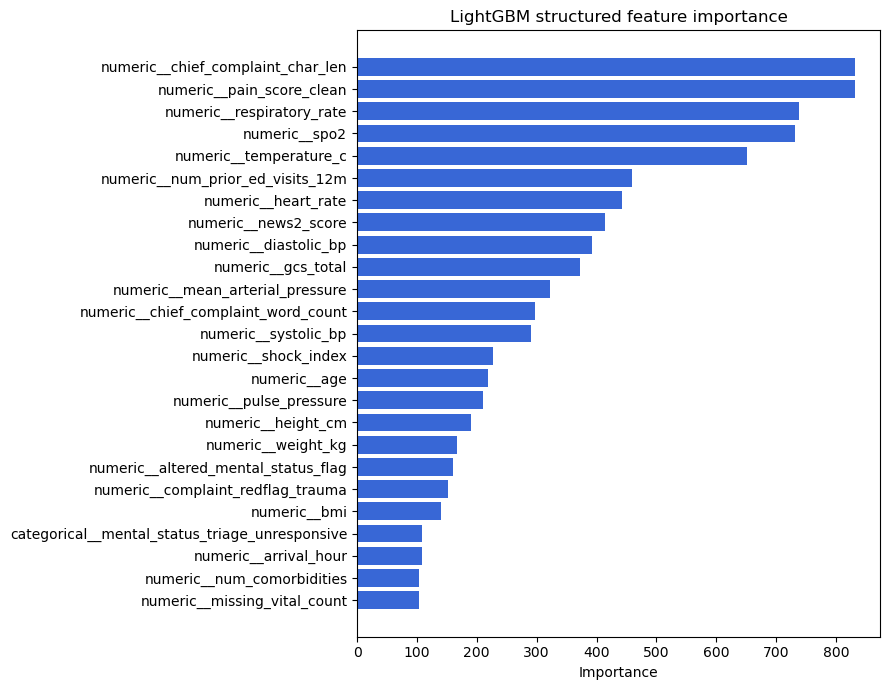

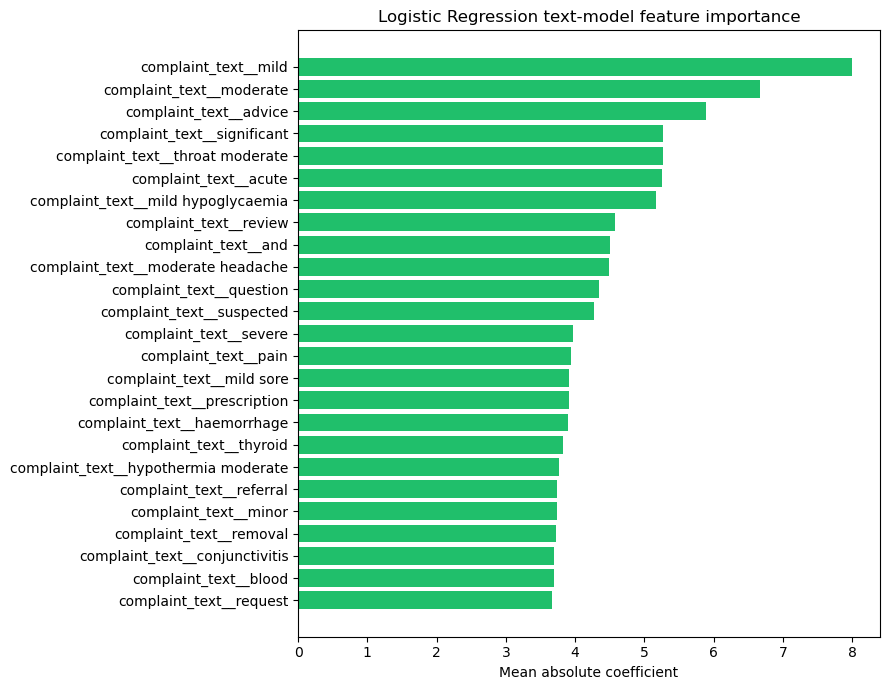

,feature,importance
57,numeric__chief_complaint_char_len,832
11,numeric__pain_score_clean,832
7,numeric__respiratory_rate,739
9,numeric__spo2,731
8,numeric__temperature_c,651
26,numeric__num_prior_ed_visits_12m,460
6,numeric__heart_rate,443
15,numeric__news2_score,414
5,numeric__diastolic_bp,393
10,numeric__gcs_total,373


,feature,mean_abs_coef
1628,complaint_text__mild,8.000
1669,complaint_text__moderate,6.664
158,complaint_text__advice,5.893
2350,complaint_text__significant,5.271
2650,complaint_text__throat moderate,5.262
117,complaint_text__acute,5.256
1644,complaint_text__mild hypoglycaemia,5.162
2207,complaint_text__review,4.572
206,complaint_text__and,4.502
1676,complaint_text__moderate headache,4.495


Wrote feature importance outputs to: data/processed/model_importance


In [51]:
def get_preprocessed_feature_names(preprocessor):
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        feature_names = []
        for name, transformer, columns in preprocessor.transformers_:
            if name == "remainder" and transformer == "drop":
                continue
            if hasattr(transformer, "get_feature_names_out"):
                try:
                    feature_names.extend(transformer.get_feature_names_out(columns))
                except TypeError:
                    feature_names.extend(transformer.get_feature_names_out())
            elif isinstance(columns, str):
                feature_names.append(columns)
            else:
                feature_names.extend(columns)
        return np.asarray(feature_names)


importance_output_dir = PROCESSED_DIR / "model_importance"
importance_output_dir.mkdir(parents=True, exist_ok=True)

lgbm_importance_params = best_tuned_params.get(("LightGBM", "full non-text structured"), {})
lgbm_importance_pipeline = make_pipeline_with_params("LightGBM", structured_spec["columns"], params=lgbm_importance_params)
fit_pipeline_for_model(lgbm_importance_pipeline, "LightGBM", train_processed[structured_spec["columns"]], y_model)
lgbm_feature_names = get_preprocessed_feature_names(lgbm_importance_pipeline.named_steps["preprocessor"])
lgbm_feature_importance = pd.DataFrame(
    {
        "feature": lgbm_feature_names,
        "importance": lgbm_importance_pipeline.named_steps["model"].feature_importances_,
    }
).sort_values("importance", ascending=False)
lgbm_feature_importance.to_csv(importance_output_dir / "lightgbm_feature_importance.csv", index=False)

top_lgbm_importance = lgbm_feature_importance.head(25).iloc[::-1]
plt.figure(figsize=(9, 7))
plt.barh(top_lgbm_importance["feature"], top_lgbm_importance["importance"], color="#3867d6")
plt.title("LightGBM structured feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(importance_output_dir / "lightgbm_feature_importance.png", dpi=160)
plt.show()

lr_importance_params = best_tuned_params.get(("Logistic Regression", "core + complaint text"), {})
lr_importance_pipeline = make_pipeline_with_params("Logistic Regression", lr_text_spec["columns"], params=lr_importance_params)
lr_importance_pipeline.fit(train_processed[lr_text_spec["columns"]], y_model)
lr_feature_names = get_preprocessed_feature_names(lr_importance_pipeline.named_steps["preprocessor"])
lr_mean_abs_coef = np.abs(lr_importance_pipeline.named_steps["model"].coef_).mean(axis=0)
lr_text_feature_importance = pd.DataFrame(
    {
        "feature": lr_feature_names,
        "mean_abs_coef": lr_mean_abs_coef,
    }
).sort_values("mean_abs_coef", ascending=False)
lr_text_feature_importance.to_csv(importance_output_dir / "logistic_text_feature_importance.csv", index=False)

top_lr_importance = lr_text_feature_importance.head(25).iloc[::-1]
plt.figure(figsize=(9, 7))
plt.barh(top_lr_importance["feature"], top_lr_importance["mean_abs_coef"], color="#20bf6b")
plt.title("Logistic Regression text-model feature importance")
plt.xlabel("Mean absolute coefficient")
plt.tight_layout()
plt.savefig(importance_output_dir / "logistic_text_feature_importance.png", dpi=160)
plt.show()

display(lgbm_feature_importance.head(20))
display(lr_text_feature_importance.head(20))
print(f"Wrote feature importance outputs to: {importance_output_dir}")


## 11. Clinical Interpretation And Limitations

The final comparison now includes single-split diagnostics, 5-fold grouped complaint-template cross-validation, compact hyperparameter searches, and a soft-voting ensemble of the top grouped-CV candidates. The ensemble is used for `submission.csv` because it combines the strongest text/template and structured signals while keeping the validation protocol grouped by `chief_complaint_raw_clean`.

Key interpretation points:

- High-acuity recall and severe undertriage remain the primary model-selection criteria because the main harm is missing acuity 1/2 patients.
- Mean +/- standard deviation across grouped folds should be reported for accuracy, quadratic weighted kappa, high-acuity recall, and severe undertriage. This is more defensible than relying on the previous single grouped holdout.
- The best text-based models perform extremely well, which is useful for Kaggle but still indicates that complaint templates carry very strong label signal.
- LightGBM and XGBoost are tuned on the full non-text structured variant to test whether nonlinear structured models can close the gap without relying on raw complaint text.
- The submission distribution is explicitly compared with the training label distribution. Material shifts should be investigated before submitting.
- Feature importance outputs quantify the relative contribution of structured clinical variables and text terms for the report.

Limitations:

- The dataset appears synthetic or highly templated, especially in chief complaint text, so external validity is uncertain.
- Strong grouped-CV performance does not prove clinical deployability; it supports competition performance under this dataset's structure.
- `disposition` and `ed_los_hours` are post-triage outcomes and were excluded from training; they cannot prove true undertriage without chart review.
- The grouped split protects against identical complaint templates crossing train/validation, but it is still internal validation. A real deployment claim would require external hospital/time validation.
- The final `submission.csv` is a competition submission candidate, not a clinically deployable triage tool.


## 12. Inference On Future Unseen Data

Future unseen data should be predicted with the exact same preprocessing and feature engineering logic used for train/test. The expected inputs are raw tables with the same structure as `test.csv`, `chief_complaints.csv`, and `patient_history.csv`.

The functions below provide a lightweight inference wrapper:

1. Apply `prepare_features(..., is_train=False)` to unseen raw inputs.
2. Check that all final model feature columns are present.
3. Run the selected final model.
4. Return a submission-style table with `patient_id` and predicted `triage_acuity`.


In [52]:
def prepare_unseen_features(main_df, complaints_df, history_df):
    """Apply the same preprocessing and feature engineering used for test data."""
    return prepare_features(main_df, complaints_df, history_df, is_train=False)


def predict_unseen_triage(main_df, complaints_df, history_df, model, feature_columns, model_name="Logistic Regression"):
    """Predict triage acuity for a future raw dataset using the selected final model."""
    unseen_processed = prepare_unseen_features(main_df, complaints_df, history_df)
    missing_features = sorted(set(feature_columns) - set(unseen_processed.columns))
    if missing_features:
        raise ValueError(f"Unseen data is missing required processed features: {missing_features}")

    if model_name == "Soft Voting Ensemble":
        predictions = model.predict(unseen_processed[feature_columns]).astype(int)
    elif model_name == "Logistic Regression":
        predictions = model.predict(unseen_processed[feature_columns]).astype(int)
    else:
        predictions = predict_pipeline_for_model(model, model_name, unseen_processed[feature_columns])

    return pd.DataFrame(
        {
            ID_COL: unseen_processed[ID_COL],
            TARGET_COL: predictions.astype(int),
        }
    )


# Demonstration using the provided test tables as the current unseen dataset.
unseen_prediction_preview = predict_unseen_triage(
    test,
    chief_complaints,
    patient_history,
    final_pipeline,
    final_feature_columns,
    final_model_name,
)

display(unseen_prediction_preview.head())
print(f"Unseen prediction rows: {len(unseen_prediction_preview):,}")


,patient_id,triage_acuity
0,TG-FZUFCRZS3,2
1,TG-SSCOXTYI1,3
2,TG-JY74ZR35D,2
3,TG-JDKD5G62X,4
4,TG-J1BSAAXR0,4


Unseen prediction rows: 20,000


### Future Validation Note

The current validation is internal. If a genuinely new labeled dataset becomes available, it should be used as an external validation set after applying the same preprocessing and feature engineering functions. Report the same clinical metrics: high-acuity recall, severe undertriage rate, macro F1, quadratic weighted kappa, MAE, and confusion matrix.


## 13. External Example Dataset Validation

This section is for validating the selected final model on a future example dataset or any external labeled dataset. The current repository does not include an additional labeled validation dataset, so this cell is written as a reusable entry point.

Expected folder structure:

```text
data/external_validation/
  main.csv                  # required; same schema as train/test-style main table
  chief_complaints.csv      # required; same schema as data/chief_complaints.csv
  patient_history.csv       # required; same schema as data/patient_history.csv
```

If `main.csv` contains `triage_acuity`, the section evaluates predictions with the same metrics used internally. If it does not contain `triage_acuity`, the section only generates predictions.


In [53]:
EXTERNAL_VALIDATION_DIR = DATA_DIR / "external_validation"
EXTERNAL_MAIN_CANDIDATES = ["main.csv", "train.csv", "test.csv"]


def find_external_main_path(external_dir=EXTERNAL_VALIDATION_DIR):
    for filename in EXTERNAL_MAIN_CANDIDATES:
        candidate = external_dir / filename
        if candidate.exists():
            return candidate
    return None


def run_external_validation(external_dir=EXTERNAL_VALIDATION_DIR):
    external_dir = Path(external_dir)
    main_path = find_external_main_path(external_dir)
    complaints_path = external_dir / "chief_complaints.csv"
    history_path = external_dir / "patient_history.csv"

    required_paths = {
        "main": main_path,
        "chief_complaints": complaints_path,
        "patient_history": history_path,
    }
    missing = [name for name, file_path in required_paths.items() if file_path is None or not file_path.exists()]
    if missing:
        print(f"External validation data not found in {external_dir}.")
        print("Add main.csv, chief_complaints.csv, and patient_history.csv to run this section.")
        print(f"Missing: {missing}")
        return None, None

    external_main = pd.read_csv(main_path)
    external_complaints = pd.read_csv(complaints_path)
    external_history = pd.read_csv(history_path)
    has_labels = TARGET_COL in external_main.columns

    external_processed = prepare_features(
        external_main,
        external_complaints,
        external_history,
        is_train=has_labels,
    )

    missing_features = sorted(set(final_feature_columns) - set(external_processed.columns))
    if missing_features:
        raise ValueError(f"External data is missing required processed features: {missing_features}")

    if final_model_name == "Soft Voting Ensemble":
        external_predictions = final_pipeline.predict(external_processed[final_feature_columns]).astype(int)
    elif final_model_name == "Logistic Regression":
        external_predictions = final_pipeline.predict(external_processed[final_feature_columns]).astype(int)
    else:
        external_predictions = predict_pipeline_for_model(final_pipeline, final_model_name, external_processed[final_feature_columns])

    prediction_table = pd.DataFrame(
        {
            ID_COL: external_processed[ID_COL],
            TARGET_COL: external_predictions.astype(int),
        }
    )

    output_path = external_dir / "external_validation_predictions.csv"
    prediction_table.to_csv(output_path, index=False)
    print(f"Wrote predictions to {output_path}")
    display(prediction_table.head())

    if has_labels:
        external_metrics = evaluate_triage_predictions(external_processed[TARGET_COL], external_predictions)
        external_metrics_df = pd.DataFrame([external_metrics])
        display(format_metric_table(external_metrics_df))

        external_confusion = pd.DataFrame(
            confusion_matrix(external_processed[TARGET_COL], external_predictions, labels=[1, 2, 3, 4, 5]),
            index=["true_1", "true_2", "true_3", "true_4", "true_5"],
            columns=["pred_1", "pred_2", "pred_3", "pred_4", "pred_5"],
        )
        display(external_confusion)
    else:
        external_metrics_df = None
        print("No triage_acuity column found in external main table; generated predictions only.")

    return prediction_table, external_metrics_df


external_predictions, external_metrics = run_external_validation()


External validation data not found in data/external_validation.
Add main.csv, chief_complaints.csv, and patient_history.csv to run this section.
Missing: ['main', 'chief_complaints', 'patient_history']


### External Validation Interpretation

When an external labeled dataset is available, compare its metrics against the internal grouped complaint validation. A meaningful drop is expected if the external data uses different complaint wording, different triage practice patterns, or comes from a less templated real-world source. The most important checks remain high-acuity recall and severe undertriage rate.
